In [1]:
# Importing basic libraries:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC_DIR = ROOT / "src"
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"

os.chdir(ROOT)

sys.path.insert(0, str(SRC_DIR))

from vae_model import ResidualVAE

# For interactive plots
import joblib
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

In [2]:
# Loading the main model paths:
vae_main_path = str(ARTIFACT_DIR)

model_weights = os.path.join(vae_main_path, "best_ResidualVAE_d8.pth")
centroids_path = os.path.join(vae_main_path, "centroids_8d_K9.npy")
labels_path = os.path.join(vae_main_path, "cluster_labels_K9.npy")
latents_path = os.path.join(vae_main_path, "latents_8d.npy")

# Loading the model weights: 1. Load model architecture 2. Load state dict 3. Map the state_dict to architecture
model = ResidualVAE()                               # create the architecture
state_dict = torch.load(model_weights, weights_only=True, map_location='cpu')
model.load_state_dict(state_dict['model_state'])    # fill weights in-place, don't assign
model.eval()                                        # set to inference mode

# Loading the numpy arrays:
centroids_d8_k9 = torch.tensor(np.load(centroids_path), dtype = torch.float32) # Loading the centroids array
labels_d8_k9 = torch.tensor(np.load(labels_path), dtype = torch.float32)
latents_d8_k9 = torch.tensor(np.load(latents_path), dtype = torch.float32)

# Printing out the shapes:
print(f"Centroids shape: {centroids_d8_k9.shape}; Latents shape: {latents_d8_k9.shape}")

Centroids shape: torch.Size([9, 8]); Latents shape: torch.Size([22400, 8])


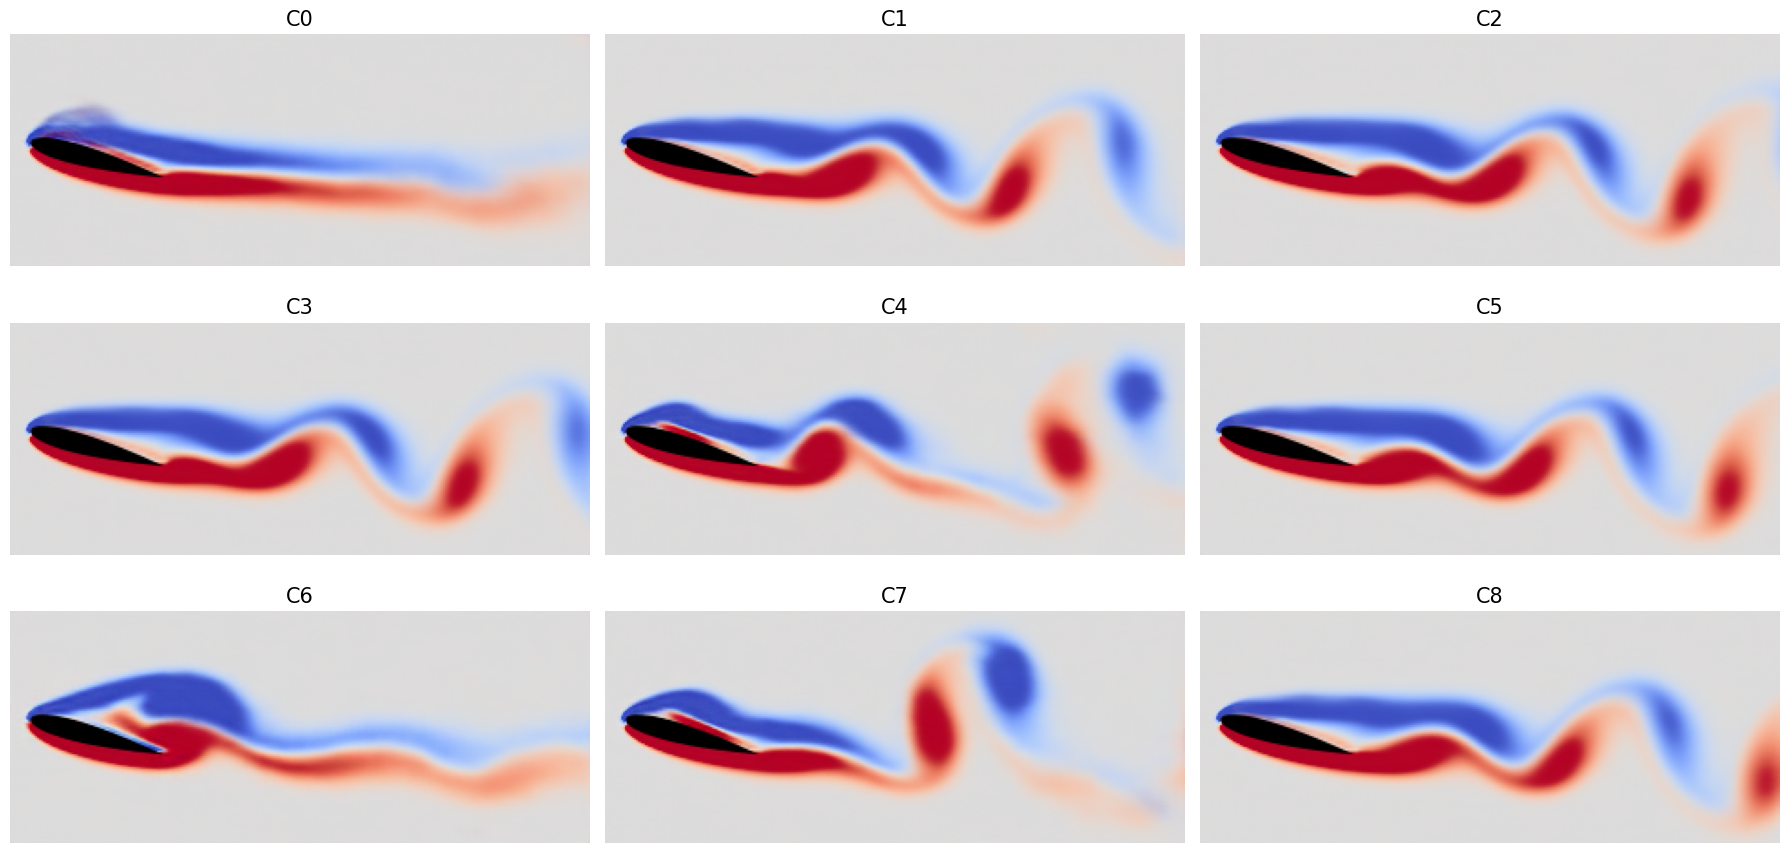

In [3]:
# Visualizing the centroids:
fig, axes = plt.subplots(3, 3, figsize=(18, 9))
for k, ax in enumerate(axes.flatten()):
    c = model.decoder(centroids_d8_k9[k].unsqueeze(0)).detach().squeeze().permute(1, 2, 0).numpy()
    ax.imshow(np.clip(c, 0, 1))
    ax.set_title(f"C{k}", fontsize=15)
    ax.axis('off')
plt.tight_layout()
plt.show()

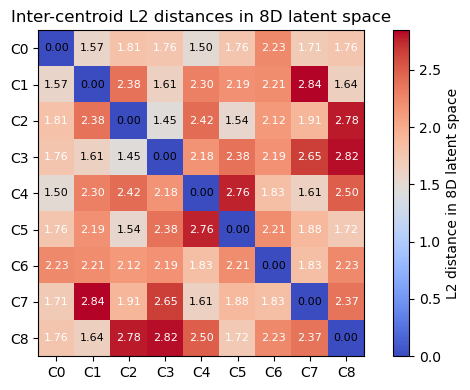

STD of C6: 0.315
STD of C7: 0.313


In [4]:
# Calculating the inter centroid distances:
m = centroids_d8_k9.shape[0]  # 9 centroids
centroid_dist_matrix = torch.zeros(m, m)
for i in range(m):
    for j in range(m):
        centroid_dist_matrix[i, j] = torch.norm(centroids_d8_k9[i] - centroids_d8_k9[j])


fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(centroid_dist_matrix.numpy(), cmap='coolwarm')
plt.colorbar(im, ax=ax, label='L2 distance in 8D latent space')
ax.set_xticks(range(m))
ax.set_yticks(range(m))
ax.set_xticklabels([f'C{k}' for k in range(m)])
ax.set_yticklabels([f'C{k}' for k in range(m)])
for i in range(m):
    for j in range(m):
        ax.text(j, i, f'{centroid_dist_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if centroid_dist_matrix[i,j] > centroid_dist_matrix.max()*0.6 else 'black')
ax.set_title('Inter-centroid L2 distances in 8D latent space')
plt.tight_layout()
plt.show()

# Quick check for the centroid c2 and c7:
print(f"STD of C6: {torch.std(latents_d8_k9[labels_d8_k9 == 6], dim=0).mean():.3f}")
print(f"STD of C7: {torch.std(latents_d8_k9[labels_d8_k9 == 7], dim=0).mean():.3f}")

## Interactive plots - Will take time.

In [5]:
umap_path = os.path.join(vae_main_path, "umap_reducer_3d.joblib")
reducer_3d = joblib.load(umap_path)

latents_np   = latents_d8_k9.numpy()
centroids_np = centroids_d8_k9.numpy()
labels_np    = labels_d8_k9.numpy().astype(int)

embedding_3d           = reducer_3d.transform(latents_np)     # (N, 3)
centroid_embedding_3d  = reducer_3d.transform(centroids_np)   # (9, 3)

# exact colors sampled from your existing dashboard legend
cluster_colors = {
    0: '#d4354f', 1: '#61b058', 2: '#fbe050', 3: '#4866d1', 4: '#e78745',
    5: '#6ed2f0', 6: '#dd4cdf', 7: '#c9ec63', 8: '#888888',
}

fig = go.Figure()

for k in range(9):
    mask = labels_np == k
    fig.add_trace(go.Scatter3d(x=embedding_3d[mask, 0], y=embedding_3d[mask, 1], z=embedding_3d[mask, 2],
        mode='markers', marker=dict(size=2.5, color=cluster_colors[k], opacity=0.6),
        name=f'C{k} (n={mask.sum()})', hovertemplate=f'C{k}<br>idx=%{{customdata}}<extra></extra>',
        customdata=np.where(mask)[0]))

# centroids as larger labeled diamonds, on top
fig.add_trace(go.Scatter3d(x=centroid_embedding_3d[:, 0], y=centroid_embedding_3d[:, 1], z=centroid_embedding_3d[:, 2],
    mode='markers+text', marker=dict(size=9, color=[cluster_colors[k] for k in range(9)], symbol='diamond',
    line=dict(color='white', width=1.5)), text=[f'C{k}' for k in range(9)], textposition='top center',
    textfont=dict(size=13, color='white'), name='centroids', showlegend=False,))

fig.update_layout(
    title="3D UMAP projection of latent space (K=9 clusters) -- click any point or centroid to decode",
    scene=dict(
        # axis lines, grid, ticks, panes, titles all off -- pure black void,
        # just the point cloud and centroids floating in it
        xaxis=dict(visible=False), yaxis=dict(visible=False),
        zaxis=dict(visible=False), bgcolor='#000000', ),
    paper_bgcolor='#000000', font=dict(color='white'), legend=dict(itemsizing='constant'),
    width=820, height=680, margin=dict(l=0, r=0, t=40, b=0))

# NEW: wrap the static figure as a clickable widget
fig_widget = go.FigureWidget(fig)

output_panel = widgets.Output(
    layout=widgets.Layout(width='420px', height='680px', border='1px solid #444',
                           padding='8px', overflow='auto'))
with output_panel:
    print("Click any point or centroid in the 3D view to decode it here.")

def _decode_latent_to_image(z_vector):
    """
    Confirmed working call: model.decoder(z) -- found via the
    TypeError you hit. z_vector arrives as a raw numpy array, so it
    still needs converting to a tensor and getting a batch dim before
    being passed in -- that conversion is the actual fix here.
    """
    model.eval()
    model_device = next(model.parameters()).device  # inferred straight from
                                                      # the model, so this
                                                      # doesn't depend on a
                                                      # `device` variable
                                                      # existing in this scope
    with torch.no_grad():
        z = torch.as_tensor(z_vector, dtype=torch.float32, device=model_device).unsqueeze(0)
        decoded = model.decoder(z)
        img = decoded.squeeze().cpu().numpy()
        if img.ndim == 3:                  # (C,H,W) -> (H,W,C) if needed
            img = np.transpose(img, (1, 2, 0))
    return img

def _show_decoded(z_vector, label, cl=None, cd=None):
    output_panel.clear_output(wait=True)
    with output_panel:
        try:
            img = _decode_latent_to_image(z_vector)
        except Exception as e:
            print(f"Decode failed -- fix _decode_latent_to_image() to match "
                  f"your model's actual decode call.\n\n{type(e).__name__}: {e}")
            return
        fig2, ax2 = plt.subplots(figsize=(5.2, 2.8))
        ax2.imshow(img)
        ax2.axis('off')
        title = label
        if cl is not None and cd is not None and cd != 0:
            title += f"\nCL={cl:.4f}  CD={cd:.4f}  CL/CD={cl/cd:.4f}"
        ax2.set_title(title, fontsize=10)
        plt.tight_layout()
        plt.show()

def _on_point_click(trace, points, state):
    if not points.point_inds:
        return
    global_idx = trace.customdata[points.point_inds[0]]
    cl = all_cl[global_idx] if 'all_cl' in globals() else None
    cd = all_cd[global_idx] if 'all_cd' in globals() else None
    _show_decoded(latents_np[global_idx],
                  label=f"sample idx={global_idx}  |  cluster C{labels_np[global_idx]}",
                  cl=cl, cd=cd)

def _on_centroid_click(trace, points, state):
    if not points.point_inds:
        return
    k = points.point_inds[0]
    _show_decoded(centroids_np[k], label=f"centroid C{k}")

# attach: traces 0-8 are the 9 clusters, trace 9 is the centroids
for k in range(9):
    fig_widget.data[k].on_click(_on_point_click)
fig_widget.data[9].on_click(_on_centroid_click)

display(widgets.HBox([fig_widget, output_panel]))

    'data': [{'customdata': {'bdata': ('hACFACwCLQIuAi8CMAIxAqgCqQLAAs' ... '4UT…

In [6]:
# Sparse "core" 3D viewer: declutters the UMAP
# projection by dropping ambiguous/transitional points, so the
# 9-cluster skeleton (disc ring + C0 bridge + C4/C7/C6 sub-loops)
# becomes visible directly in the point cloud, not just in the
# centroid-distance graph from earlier cells.

# FILTER: margin-based confidence, not "distance from own centroid".
# A point is kept only if it's notably closer to its own assigned
# centroid than to the next-closest OTHER centroid -- this targets
# boundary/transitional points specifically, and is unaffected by
# whether any cluster's internal shape is unimodal, elongated, or
# secretly multimodal (it never references a cluster's own mean
# position at all, only relative distances).


latents_np   = latents_d8_k9.numpy()
centroids_np = centroids_d8_k9.numpy()
labels_np    = labels_d8_k9.numpy().astype(int)

# distance from every point to every one of the 9 centroids -- (N, 9)
dists_to_all_centroids = np.linalg.norm(
    latents_np[:, None, :] - centroids_np[None, :, :], axis=2
)
own_dist = dists_to_all_centroids[np.arange(len(labels_np)), labels_np]

masked = dists_to_all_centroids.copy()
masked[np.arange(len(labels_np)), labels_np] = np.inf
second_dist = masked.min(axis=1)

# >1 = closer to own centroid (correctly assigned); higher = more
# confidently "core", farther from any boundary with a neighbor
margin_ratio = second_dist / own_dist

print("How many points survive at a few candidate thresholds "
      "(higher threshold = sparser, more conservative):\n")
for thresh in [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]:
    kept = margin_ratio >= thresh
    print(f"  threshold {thresh:.1f}: {kept.sum():6d} / {len(labels_np)} "
          f"retained overall ({100*kept.sum()/len(labels_np):4.1f}%)")

How many points survive at a few candidate thresholds (higher threshold = sparser, more conservative):

  threshold 1.6:  12207 / 22400 retained overall (54.5%)
  threshold 1.8:  10148 / 22400 retained overall (45.3%)
  threshold 2.0:   8453 / 22400 retained overall (37.7%)
  threshold 2.2:   6950 / 22400 retained overall (31.0%)
  threshold 2.4:   5866 / 22400 retained overall (26.2%)
  threshold 2.6:   4846 / 22400 retained overall (21.6%)
  threshold 2.8:   3947 / 22400 retained overall (17.6%)
  threshold 3.0:   3347 / 22400 retained overall (14.9%)



Using threshold = 2.0. Per-cluster breakdown:
  C0:   438 /  2027 kept (21.6%)
  C1:  1862 /  3738 kept (49.8%)
  C2:  1188 /  2439 kept (48.7%)
  C3:  1466 /  2928 kept (50.1%)
  C4:   329 /  2134 kept (15.4%)
  C5:  1338 /  2967 kept (45.1%)
  C6:   373 /  1855 kept (20.1%)
  C7:   332 /  1867 kept (17.8%)
  C8:  1127 /  2445 kept (46.1%)


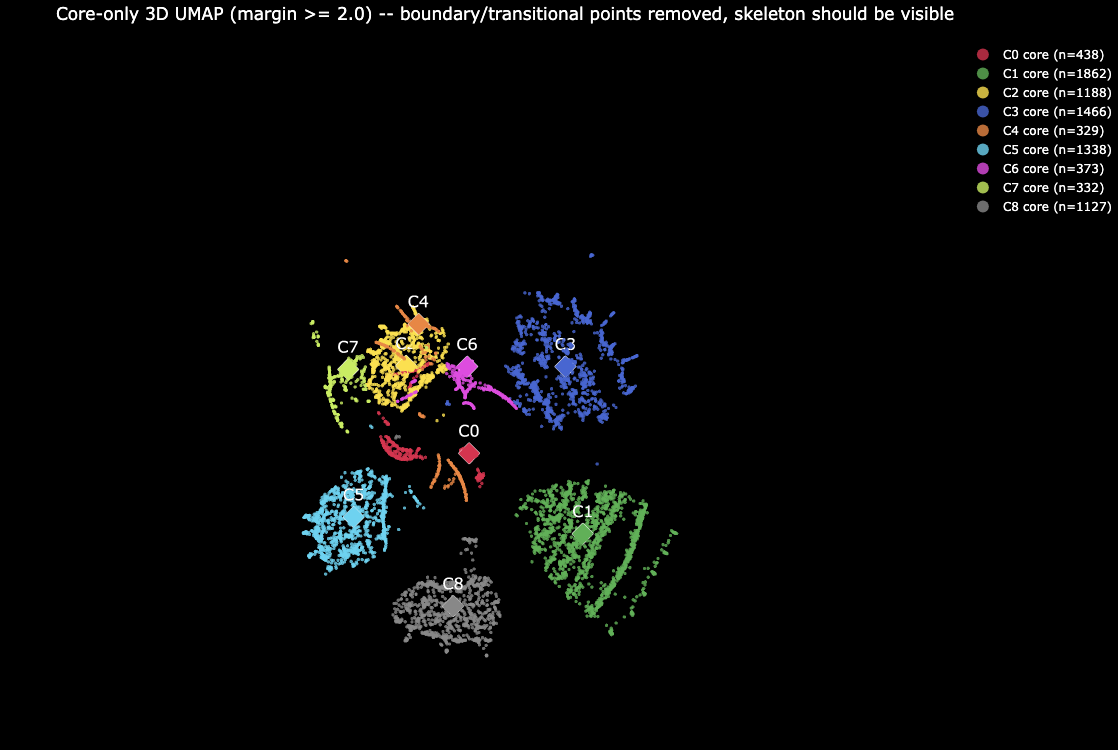

In [7]:
# pick the threshold here once you've looked at the sweep above
MARGIN_THRESHOLD = 2.0 # This controls how core centric the umap will be!
core_mask = margin_ratio >= MARGIN_THRESHOLD

print(f"\nUsing threshold = {MARGIN_THRESHOLD}. Per-cluster breakdown:")
for k in range(9):
    in_k = labels_np == k
    kept_k = core_mask[in_k].sum()
    print(f"  C{k}: {kept_k:5d} / {in_k.sum():5d} kept "
          f"({100*kept_k/in_k.sum():4.1f}%)")

# project only the retained points through the existing,
# already-fitted reducer -- still no refitting
embedding_3d_core = reducer_3d.transform(latents_np[core_mask])
labels_core       = labels_np[core_mask]
centroid_embedding_3d = reducer_3d.transform(centroids_np)

cluster_colors = {
    0: '#d4354f', 1: '#61b058', 2: '#fbe050', 3: '#4866d1', 4: '#e78745',
    5: '#6ed2f0', 6: '#dd4cdf', 7: '#c9ec63', 8: '#888888',
}

fig_core = go.Figure()
for k in range(9):
    mask = labels_core == k
    fig_core.add_trace(go.Scatter3d(
        x=embedding_3d_core[mask, 0], y=embedding_3d_core[mask, 1], z=embedding_3d_core[mask, 2],
        mode='markers', marker=dict(size=2, color=cluster_colors[k], opacity=0.8), name=f'C{k} core (n={mask.sum()})'))

fig_core.add_trace(go.Scatter3d(
    x=centroid_embedding_3d[:, 0], y=centroid_embedding_3d[:, 1], z=centroid_embedding_3d[:, 2], mode='markers+text',
    marker=dict(size=10, color=[cluster_colors[k] for k in range(9)], symbol='diamond', line=dict(color='white', width=1.5)),
    text=[f'C{k}' for k in range(9)], textposition='top center', textfont=dict(size=16, color='white'), name='centroids', showlegend=False))

fig_core.update_layout(
    title=f"Core-only 3D UMAP (margin >= {MARGIN_THRESHOLD}) -- "
          f"boundary/transitional points removed, skeleton should be visible",
    scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False), bgcolor='#000000'),
    paper_bgcolor='#000000', font=dict(color='white'), legend=dict(itemsizing='constant'), width=950, height=750,
    margin=dict(l=0, r=0, t=40, b=0))

fig_core.show()

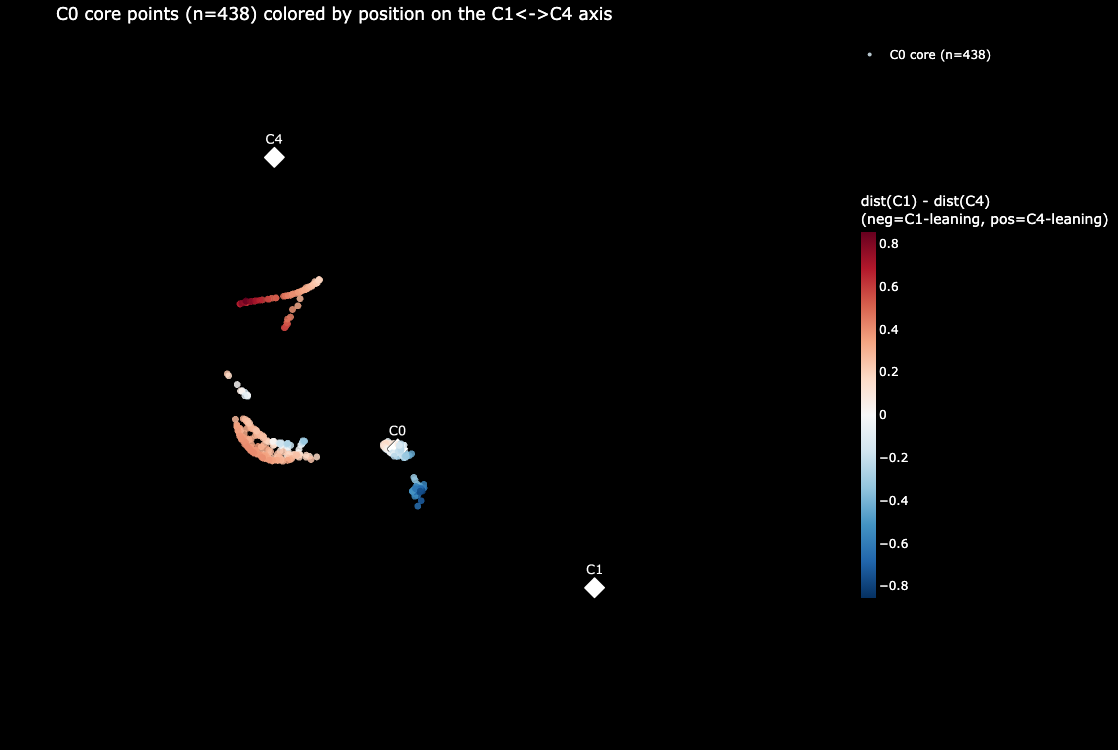

axis_value range: [-0.79, 0.85]
axis_value std:    0.342


In [8]:
c0_core_mask = core_mask & (labels_np == 0)
c0_core_idx  = np.where(c0_core_mask)[0]

c0_latents = latents_np[c0_core_idx]
dist_to_C1 = np.linalg.norm(c0_latents - centroids_np[1], axis=1)
dist_to_C4 = np.linalg.norm(c0_latents - centroids_np[4], axis=1)

# negative = closer to C1 (disc-leaning), positive = closer to C4 (branch-leaning)
axis_value = dist_to_C1 - dist_to_C4

c0_embedding = reducer_3d.transform(c0_latents)  # same fitted reducer, no refit

fig_grad = go.Figure()

fig_grad.add_trace(go.Scatter3d(x=c0_embedding[:, 0], y=c0_embedding[:, 1], z=c0_embedding[:, 2], mode='markers',
    marker=dict(size=4, color=axis_value, colorscale='RdBu_r', cmid=0,
        colorbar=dict(title='dist(C1) - dist(C4)<br>(neg=C1-leaning, pos=C4-leaning)', thickness=15, len=0.6), opacity=0.85),
    name=f'C0 core (n={len(c0_core_idx)})', hovertemplate='idx=%{customdata}<br>axis=%{marker.color:.2f}<extra></extra>',
                                customdata=c0_core_idx))

# C0 / C1 / C4 centroids shown for reference
for k, label in [(0, 'C0'), (1, 'C1'), (4, 'C4')]:
    cen = reducer_3d.transform(centroids_np[k:k+1])[0]
    fig_grad.add_trace(go.Scatter3d(x=[cen[0]], y=[cen[1]], z=[cen[2]], mode='markers+text',
        marker=dict(size=10, color='white', symbol='diamond', line=dict(color='black', width=1.5)),
        text=[label], textposition='top center', textfont=dict(size=13, color='white'), showlegend=False))

fig_grad.update_layout(
    title=f"C0 core points (n={len(c0_core_idx)}) colored by position on the C1<->C4 axis",
    scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False),
        bgcolor='#000000'), paper_bgcolor='#000000', font=dict(color='white'), width=950, height=750, margin=dict(l=0, r=0, t=40, b=0))
fig_grad.show()

print(f"axis_value range: [{axis_value.min():.2f}, {axis_value.max():.2f}]")
print(f"axis_value std:    {axis_value.std():.3f}")

# Latent Geometry

In [9]:
# GEOMETRY FIGURE — matrix (left) + skeleton (center) + C0 anisotropy (right)
#   Edge style by 8D distance: < SOLID_MAX solid, [SOLID_MAX, DASH_MAX] dashed.
#   Thickness ∝ closeness. Panel 2 keeps full topology; labels only on C0 edges.

import matplotlib.patheffects as pe
from mpl_toolkits.mplot3d import Axes3D            # noqa
from mpl_toolkits.mplot3d import proj3d

# knobs
MARGIN_THRESHOLD = 2.0
SHOW_SKELETON    = True
SOLID_MAX        = 1.75
DASH_MAX         = 1.85
VIEW_ELEV        = 0
VIEW_AZIM        = 50
ZOOM             = 0.88
SAVE_STEM        = f"geometry_margin_{'all' if MARGIN_THRESHOLD is None else MARGIN_THRESHOLD}"

# panel-2 edge display
# Left matrix already lists every distance, so don't repeat numbers here.
C0_EDGES_ONLY       = False   # True -> draw ONLY C0's spokes (hub star; drops community structure)
LABEL_C0_EDGES_ONLY = True    # True -> draw all edges, but label only C0's edges with distances

latents_np   = latents_d8_k9.numpy()
centroids_np = centroids_d8_k9.numpy()
labels_np    = labels_d8_k9.numpy().astype(int)
emb_pts = reducer_3d.transform(latents_np)
emb_cen = reducer_3d.transform(centroids_np)

cluster_colors = {0:'#d4354f',1:'#61b058',2:'#fbe050',3:'#4866d1',4:'#e78745',
                  5:'#6ed2f0',6:'#dd4cdf',7:'#c9ec63',8:'#888888'}

D   = np.linalg.norm(latents_np[:,None,:] - centroids_np[None,:,:], axis=2)
own = D[np.arange(len(labels_np)), labels_np]
D2  = D.copy(); D2[np.arange(len(labels_np)), labels_np] = np.inf
margin_ratio = D2.min(axis=1) / own
keep = np.ones(len(labels_np), bool) if MARGIN_THRESHOLD is None else (margin_ratio >= MARGIN_THRESHOLD)
Dc  = np.linalg.norm(centroids_np[:,None,:] - centroids_np[None,:,:], axis=2)

C0 axis_value (8D): mean +0.057, median +0.202
  C1-leaning (<-0.1): 35%   near 0 (±0.1): 9%   C4-leaning (>0.1): 56%


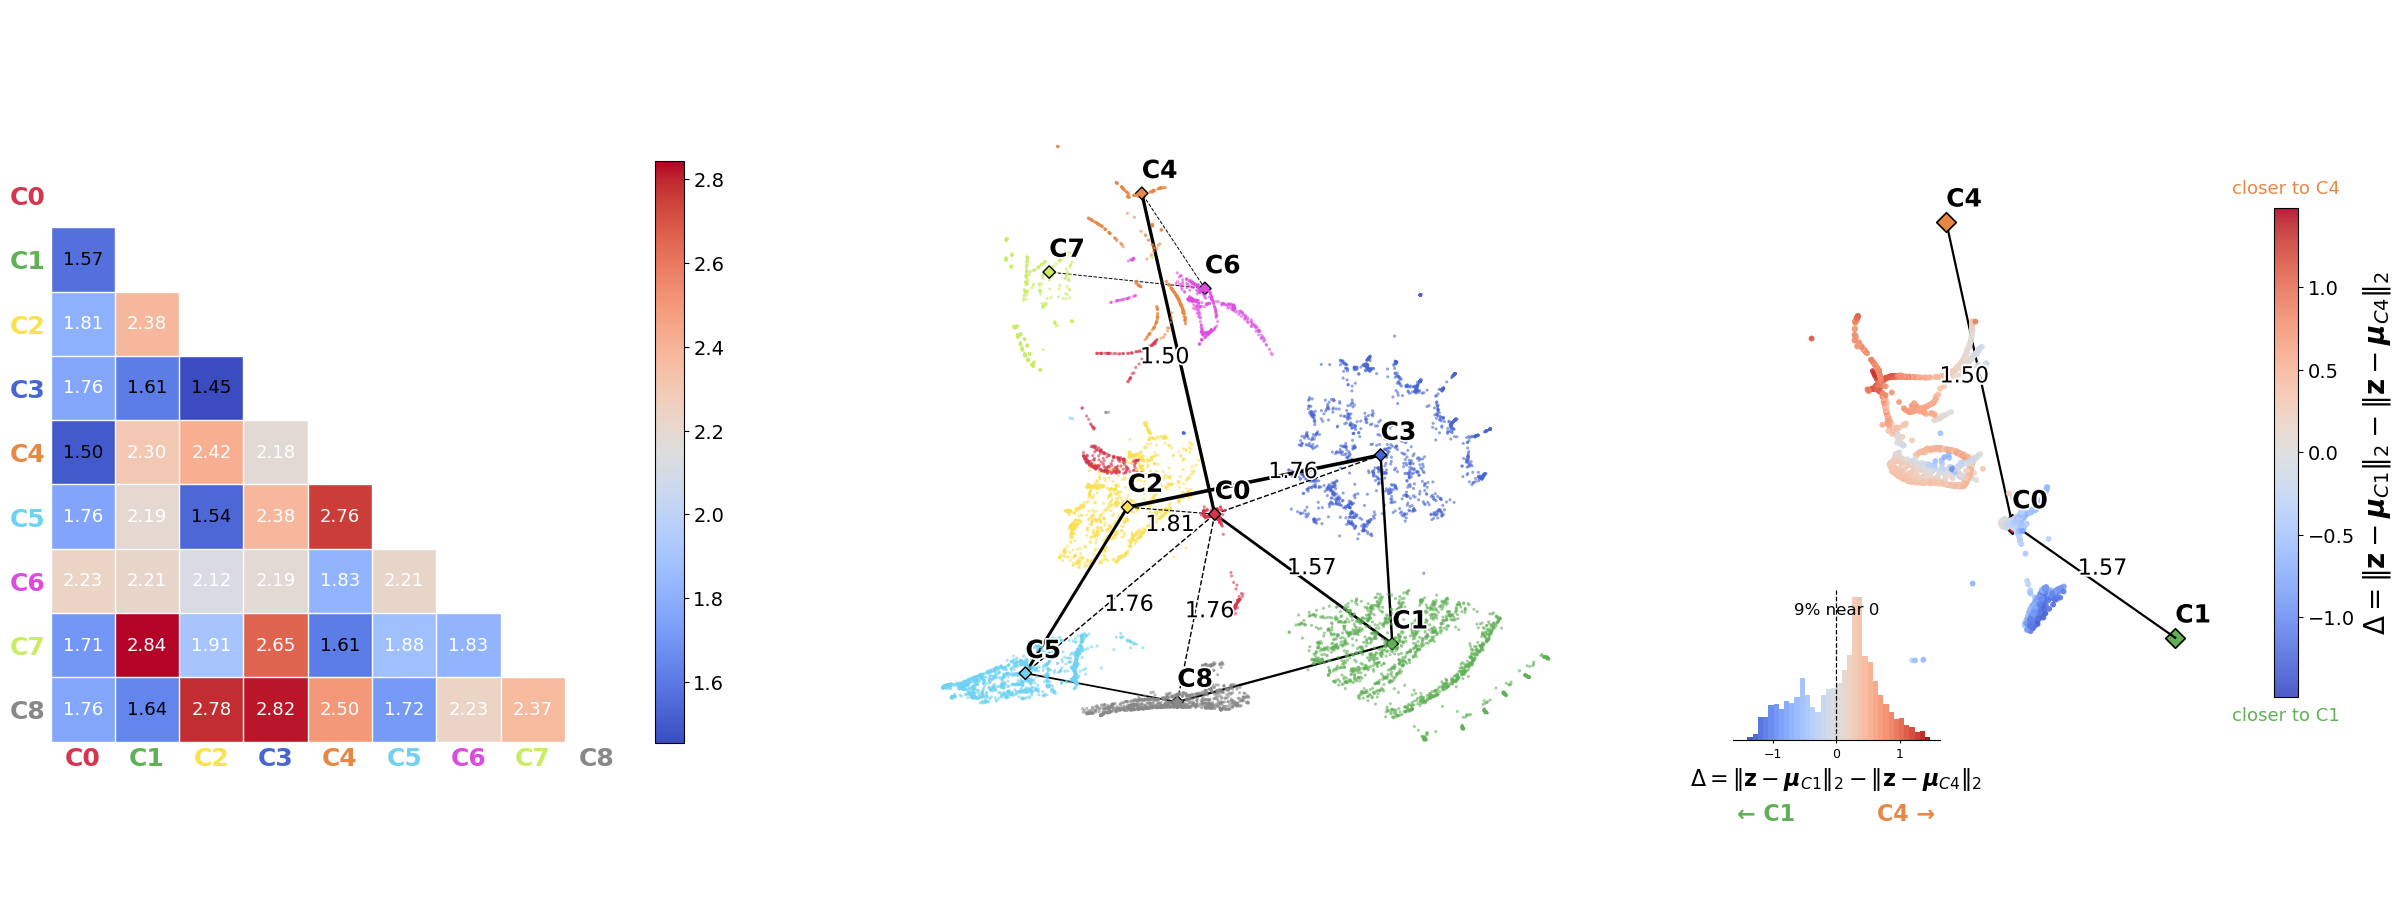

In [10]:
fig = plt.figure(figsize=(29, 11.5), facecolor='white')          # slightly wider to keep panels big after restoring a small gap
gs  = fig.add_gridspec(1, 3, width_ratios=[1.45, 2.1, 1.4], wspace=0.06)
#   ^ wspace 0.0 -> 0.06 : zero gap was CROPPING the left colorbar numbers (subplot 2 overlapped them).
#     left ratio 1.35 -> 1.45 keeps the matrix large despite the restored gap.

# LEFT: 8D inter-centroid distance matrix
axm = fig.add_subplot(gs[0, 0], facecolor='white')
M = Dc.copy()
tri = np.tril(np.ones_like(M, dtype=bool), k=-1)     # strictly lower triangle
Mm = np.ma.array(M, mask=~tri)
cmap_m = plt.cm.coolwarm.copy(); cmap_m.set_bad('white')
im = axm.imshow(Mm, cmap=cmap_m, origin='upper')
axm.set_xticks(range(9)); axm.set_yticks(range(9))
axm.set_xticklabels([f'C{k}' for k in range(9)], fontsize=18)   # centroid labels -> 18
axm.set_yticklabels([f'C{k}' for k in range(9)], fontsize=18)   # centroid labels -> 18
for k, t in enumerate(axm.get_xticklabels()): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
for k, t in enumerate(axm.get_yticklabels()): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
axm.set_xticks(np.arange(-.5, 9, 1), minor=True)
axm.set_yticks(np.arange(-.5, 9, 1), minor=True)
axm.grid(which='minor', color='white', linewidth=1.0)
axm.tick_params(which='both', length=0)
for sp in axm.spines.values(): sp.set_visible(False)
for i in range(9):
    for j in range(9):
        if tri[i, j]:
            val = M[i, j]
            txt = 'white' if val > 0.6*M.max() else 'black'
            axm.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=13, color=txt)  # matrix cell numbers
cb = fig.colorbar(im, ax=axm, fraction=0.046, pad=0.04)
cb.ax.tick_params(labelsize=14)      # left-colorbar tick-number font
# (title removed)

# CENTER: skeleton
ax  = fig.add_subplot(gs[0, 1], projection='3d', facecolor='white')
ax.set_axis_off(); ax.patch.set_alpha(0)     # transparent bg so it can't paint over the left colorbar labels
halo = [pe.withStroke(linewidth=2.5, foreground='white')]

a, sz = (0.05, 2) if MARGIN_THRESHOLD is None else (0.45, 5)
for k in range(9):
    m = keep & (labels_np == k)
    ax.scatter(emb_pts[m,0], emb_pts[m,1], emb_pts[m,2],
               s=sz, c=cluster_colors[k], alpha=0.60, edgecolors='none', depthshade=False)
ax.scatter(emb_cen[:,0], emb_cen[:,1], emb_cen[:,2], s=40,
           c=[cluster_colors[k] for k in range(9)], marker='D',
           edgecolors='black', linewidths=1.0, depthshade=False, zorder=5)

ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
try:
    ax.set_box_aspect((np.ptp(emb_pts[:,0]), np.ptp(emb_pts[:,1]), np.ptp(emb_pts[:,2])))
except Exception:
    pass
for setlim, lo, hi in [
    (ax.set_xlim3d, emb_pts[:,0].min(), emb_pts[:,0].max()),
    (ax.set_ylim3d, emb_pts[:,1].min(), emb_pts[:,1].max()),
    (ax.set_zlim3d, emb_pts[:,2].min(), emb_pts[:,2].max()),
]:
    c = 0.5*(lo+hi); r = 0.5*(hi-lo)*ZOOM
    setlim(c-r, c+r)
fig.canvas.draw()

def screen_xy_ax(axis, p3):
    x, y, _ = proj3d.proj_transform(p3[0], p3[1], p3[2], axis.get_proj())
    return np.array([x, y])

if SHOW_SKELETON:
    if C0_EDGES_ONLY:
        EDGES = [(0, 1), (0, 2), (0, 3), (0, 5), (0, 8), (0, 4)]
    else:
        EDGES = [
            (5, 2), (2, 8), (8, 1), (1, 3), (3, 5),   # disc ring cycle
            (2, 3), (5, 8),                           # disc ring chords
            (0, 1), (0, 2), (0, 3), (0, 5), (0, 8),   # C0 -> disc
            (0, 4),                                   # C0 -> branch
            (6, 4), (6, 7),                           # branch internal
        ]
    EDGES = [(i, j) for (i, j) in EDGES if Dc[i, j] <= DASH_MAX]
    _w = np.array([Dc[i, j] for i, j in EDGES]); wmin, wmax = _w.min(), _w.max()
    LW_THICK, LW_THIN = 2.6, 0.7
    def lw_for(d):
        t = 0.0 if wmax == wmin else (d - wmin) / (wmax - wmin)
        return LW_THICK + t * (LW_THIN - LW_THICK)
    for i, j in EDGES:
        d = Dc[i, j]; style = '-' if d < SOLID_MAX else '--'
        xi, xj = emb_cen[i], emb_cen[j]
        ax.plot([xi[0],xj[0]], [xi[1],xj[1]], [xi[2],xj[2]],
                color='black', lw=lw_for(d), linestyle=style, zorder=4)
    for i, j in EDGES:
        if LABEL_C0_EDGES_ONLY and (0 not in (i, j)):
            continue                                   # skip labels on non-C0 edges
        d = Dc[i, j]
        si, sj = screen_xy_ax(ax, emb_cen[i]), screen_xy_ax(ax, emb_cen[j])
        mid = 0.5*(si+sj); t = sj - si; n = np.array([-t[1], t[0]]); n = n/(np.linalg.norm(n)+1e-9)
        off = 10.0 * n
        ax.annotate(f'{d:.2f}', xy=(mid[0],mid[1]), xycoords='data',
                    xytext=(off[0],off[1]), textcoords='offset points',
                    color='black', fontsize=16, ha='center', va='center',   # skeleton edge-distance labels
                    zorder=9, annotation_clip=False, path_effects=halo)
for k in range(9):
    s = screen_xy_ax(ax, emb_cen[k])
    ax.annotate(f'C{k}', xy=(s[0], s[1]), xycoords='data',
                xytext=(0, 11), textcoords='offset points',
                color='black', fontsize=18, fontweight='bold',            # centroid labels -> 18
                zorder=30, annotation_clip=False, path_effects=halo)

# RIGHT: C0 anisotropy along the C1<->C4 axis
ax3 = fig.add_subplot(gs[0, 2], projection='3d', facecolor='white')
ax3.set_axis_off(); ax3.patch.set_alpha(0)   # transparent bg (same insurance as the skeleton panel)

c0_idx     = np.where(labels_np == 0)[0]
c0_latents = latents_np[c0_idx]
dist_to_C1 = np.linalg.norm(c0_latents - centroids_np[1], axis=1)
dist_to_C4 = np.linalg.norm(c0_latents - centroids_np[4], axis=1)
axis_value = dist_to_C1 - dist_to_C4                 # <0 C1-leaning, >0 C4-leaning
c0_emb     = reducer_3d.transform(c0_latents)

vlim = np.abs(axis_value).max()
sc = ax3.scatter(c0_emb[:,0], c0_emb[:,1], c0_emb[:,2],
                 c=axis_value, cmap='coolwarm', vmin=-vlim, vmax=vlim,
                 s=18, alpha=0.9, edgecolors='none', depthshade=False)

for k in (0, 1, 4):
    ax3.scatter(*emb_cen[k], s=100, c=cluster_colors[k], marker='D',
                edgecolors='black', linewidths=1.2, depthshade=False, zorder=6)

ax3.view_init(elev=-5, azim=VIEW_AZIM)

pts_all = np.vstack([c0_emb, emb_cen[[0,1,4]]])
rng = np.ptp(pts_all, axis=0); rng[rng == 0] = 1
try:
    ax3.set_box_aspect(tuple(rng))
except Exception:
    pass
for setlim, lo, hi in [
    (ax3.set_xlim3d, pts_all[:,0].min(), pts_all[:,0].max()),
    (ax3.set_ylim3d, pts_all[:,1].min(), pts_all[:,1].max()),
    (ax3.set_zlim3d, pts_all[:,2].min(), pts_all[:,2].max()),
]:
    c = 0.5*(lo+hi); r = 0.5*(hi-lo)*0.95
    setlim(c-r, c+r)
fig.canvas.draw()

for (i, j) in [(0, 1), (0, 4)]:
    xi, xj = emb_cen[i], emb_cen[j]
    ax3.plot([xi[0],xj[0]], [xi[1],xj[1]], [xi[2],xj[2]],
             color='black', lw=1.6, linestyle='-', zorder=4)
    si, sj = screen_xy_ax(ax3, emb_cen[i]), screen_xy_ax(ax3, emb_cen[j])
    mid = 0.5*(si+sj); t = sj - si; n = np.array([-t[1], t[0]]); n = n/(np.linalg.norm(n)+1e-9)
    ax3.annotate(f'{Dc[i,j]:.2f}', xy=(mid[0],mid[1]), xycoords='data',
                 xytext=(11*n[0], 11*n[1]), textcoords='offset points',
                 color='black', fontsize=16, ha='center', va='center',   # anisotropy C0–C1 / C0–C4 distance labels
                 zorder=9, annotation_clip=False,
                 path_effects=[pe.withStroke(linewidth=3.0, foreground='white')])

for k in (0, 1, 4):
    s = screen_xy_ax(ax3, emb_cen[k])
    ax3.annotate(f'C{k}', xy=(s[0], s[1]), xycoords='data',
                 xytext=(0, 11), textcoords='offset points',
                 color='black', fontsize=18, fontweight='bold',           # centroid labels -> 18
                 zorder=30, annotation_clip=False,
                 path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

cb3 = fig.colorbar(sc, ax=ax3, fraction=0.04, pad=0.02)
cb3.set_label(r'$\Delta = \|\mathbf{z}-\boldsymbol{\mu}_{C1}\|_2 - \|\mathbf{z}-\boldsymbol{\mu}_{C4}\|_2$',
              fontsize=20)                # anisotropy colorbar text label (the Δ definition)
cb3.ax.tick_params(labelsize=14)          # anisotropy colorbar tick-number font
cb3.ax.text(0.5, 1.02, 'closer to C4', transform=cb3.ax.transAxes,
            ha='center', va='bottom', fontsize=13, color=cluster_colors[4])
cb3.ax.text(0.5, -0.02, 'closer to C1', transform=cb3.ax.transAxes,
            ha='center', va='top', fontsize=13, color=cluster_colors[1])


# inset histogram of the signed axis (nudged toward panel center)
from matplotlib.colors import Normalize
iax = ax3.inset_axes([0.08, 0.0, 0.36, 0.26])
counts, edges = np.histogram(axis_value, bins=36, range=(-vlim, vlim))
centers = 0.5*(edges[:-1] + edges[1:])
bar_colors = plt.cm.coolwarm(Normalize(-vlim, vlim)(centers))
iax.bar(centers, counts, width=(edges[1]-edges[0]), color=bar_colors, edgecolor='none')
iax.axvline(0, color='black', lw=0.9, ls='--')
iax.set_yticks([])
iax.tick_params(axis='x', labelsize=9, length=2)
for sp in ('top', 'right', 'left'): iax.spines[sp].set_visible(False)
iax.set_xlabel(r'$\Delta = \|\mathbf{z}-\boldsymbol{\mu}_{C1}\|_2 - \|\mathbf{z}-\boldsymbol{\mu}_{C4}\|_2$',
               fontsize=16)
iax.set_facecolor('none')
near0 = ((axis_value >= -0.1) & (axis_value <= 0.1)).mean()*100
iax.text(0.5, 0.92, f'{near0:.0f}% near 0', transform=iax.transAxes,
         ha='center', va='top', fontsize=12, color='black')
iax.text(0.02, -0.42, '← C1', transform=iax.transAxes, ha='left', va='top',
         fontsize=16, color=cluster_colors[1], fontweight='bold')
iax.text(0.98, -0.42, 'C4 →', transform=iax.transAxes, ha='right', va='top',
         fontsize=16, color=cluster_colors[4], fontweight='bold')

print(f"C0 axis_value (8D): mean {axis_value.mean():+.3f}, median {np.median(axis_value):+.3f}")
print(f"  C1-leaning (<-0.1): {(axis_value<-0.1).mean()*100:.0f}%   "
      f"near 0 (±0.1): {((axis_value>=-0.1)&(axis_value<=0.1)).mean()*100:.0f}%   "
      f"C4-leaning (>0.1): {(axis_value>0.1).mean()*100:.0f}%")



# fig.savefig(f'{SAVE_STEM}_threepanel.png', dpi=500, facecolor='white', bbox_inches='tight')
plt.show()

# CL/CD ration per cluster.

In [11]:
all_cl = np.load(os.path.join(vae_main_path, "all_cl.npy"))
all_cd = np.load(os.path.join(vae_main_path, "all_cd.npy"))
ratio = all_cl / all_cd

labels = labels_d8_k9.numpy().astype(int)
assert len(ratio) == len(labels), f"length mismatch: ratio={len(ratio)} vs labels={len(labels)}"

K = 9

# Approach A: mean of instantaneous CL/CD
clcd_mean_ratio = np.array([ratio[labels == k].mean() for k in range(K)])

# Approach B: mean CL divided by mean CD
cl_mean = np.array([all_cl[labels == k].mean() for k in range(K)])
cd_mean = np.array([all_cd[labels == k].mean() for k in range(K)])
clcd_ratio_means = cl_mean / cd_mean

# Useful extra statistics
clcd_median = np.array([np.median(ratio[labels == k]) for k in range(K)])
clcd_std = np.array([ratio[labels == k].std() for k in range(K)])
clcd_n = np.array([(labels == k).sum() for k in range(K)])

print(f"{'Cluster':>8} {'<CL/CD>':>10} {'<CL>/<CD>':>12} {'difference':>12}")
print("-" * 46)

for k in range(K):
    diff = clcd_mean_ratio[k] - clcd_ratio_means[k]
    print(f"C{k:>7} {clcd_mean_ratio[k]:>10.3f} {clcd_ratio_means[k]:>12.3f} {diff:>12.3f}")

print("\nRanking by <CL/CD>:")
print([f"C{k}" for k in np.argsort(clcd_mean_ratio)[::-1]])

print("\nRanking by <CL>/<CD>:")
print([f"C{k}" for k in np.argsort(clcd_ratio_means)[::-1]])

 Cluster    <CL/CD>    <CL>/<CD>   difference
----------------------------------------------
C      0      2.463        2.477       -0.014
C      1      2.150        2.149        0.001
C      2      2.040        2.042       -0.002
C      3      2.044        2.047       -0.003
C      4      2.431        2.438       -0.007
C      5      2.062        2.063       -0.000
C      6      1.654        1.651        0.002
C      7      2.236        2.230        0.006
C      8      2.158        2.159       -0.000

Ranking by <CL/CD>:
['C0', 'C4', 'C7', 'C8', 'C1', 'C5', 'C3', 'C2', 'C6']

Ranking by <CL>/<CD>:
['C0', 'C4', 'C7', 'C8', 'C1', 'C5', 'C3', 'C2', 'C6']


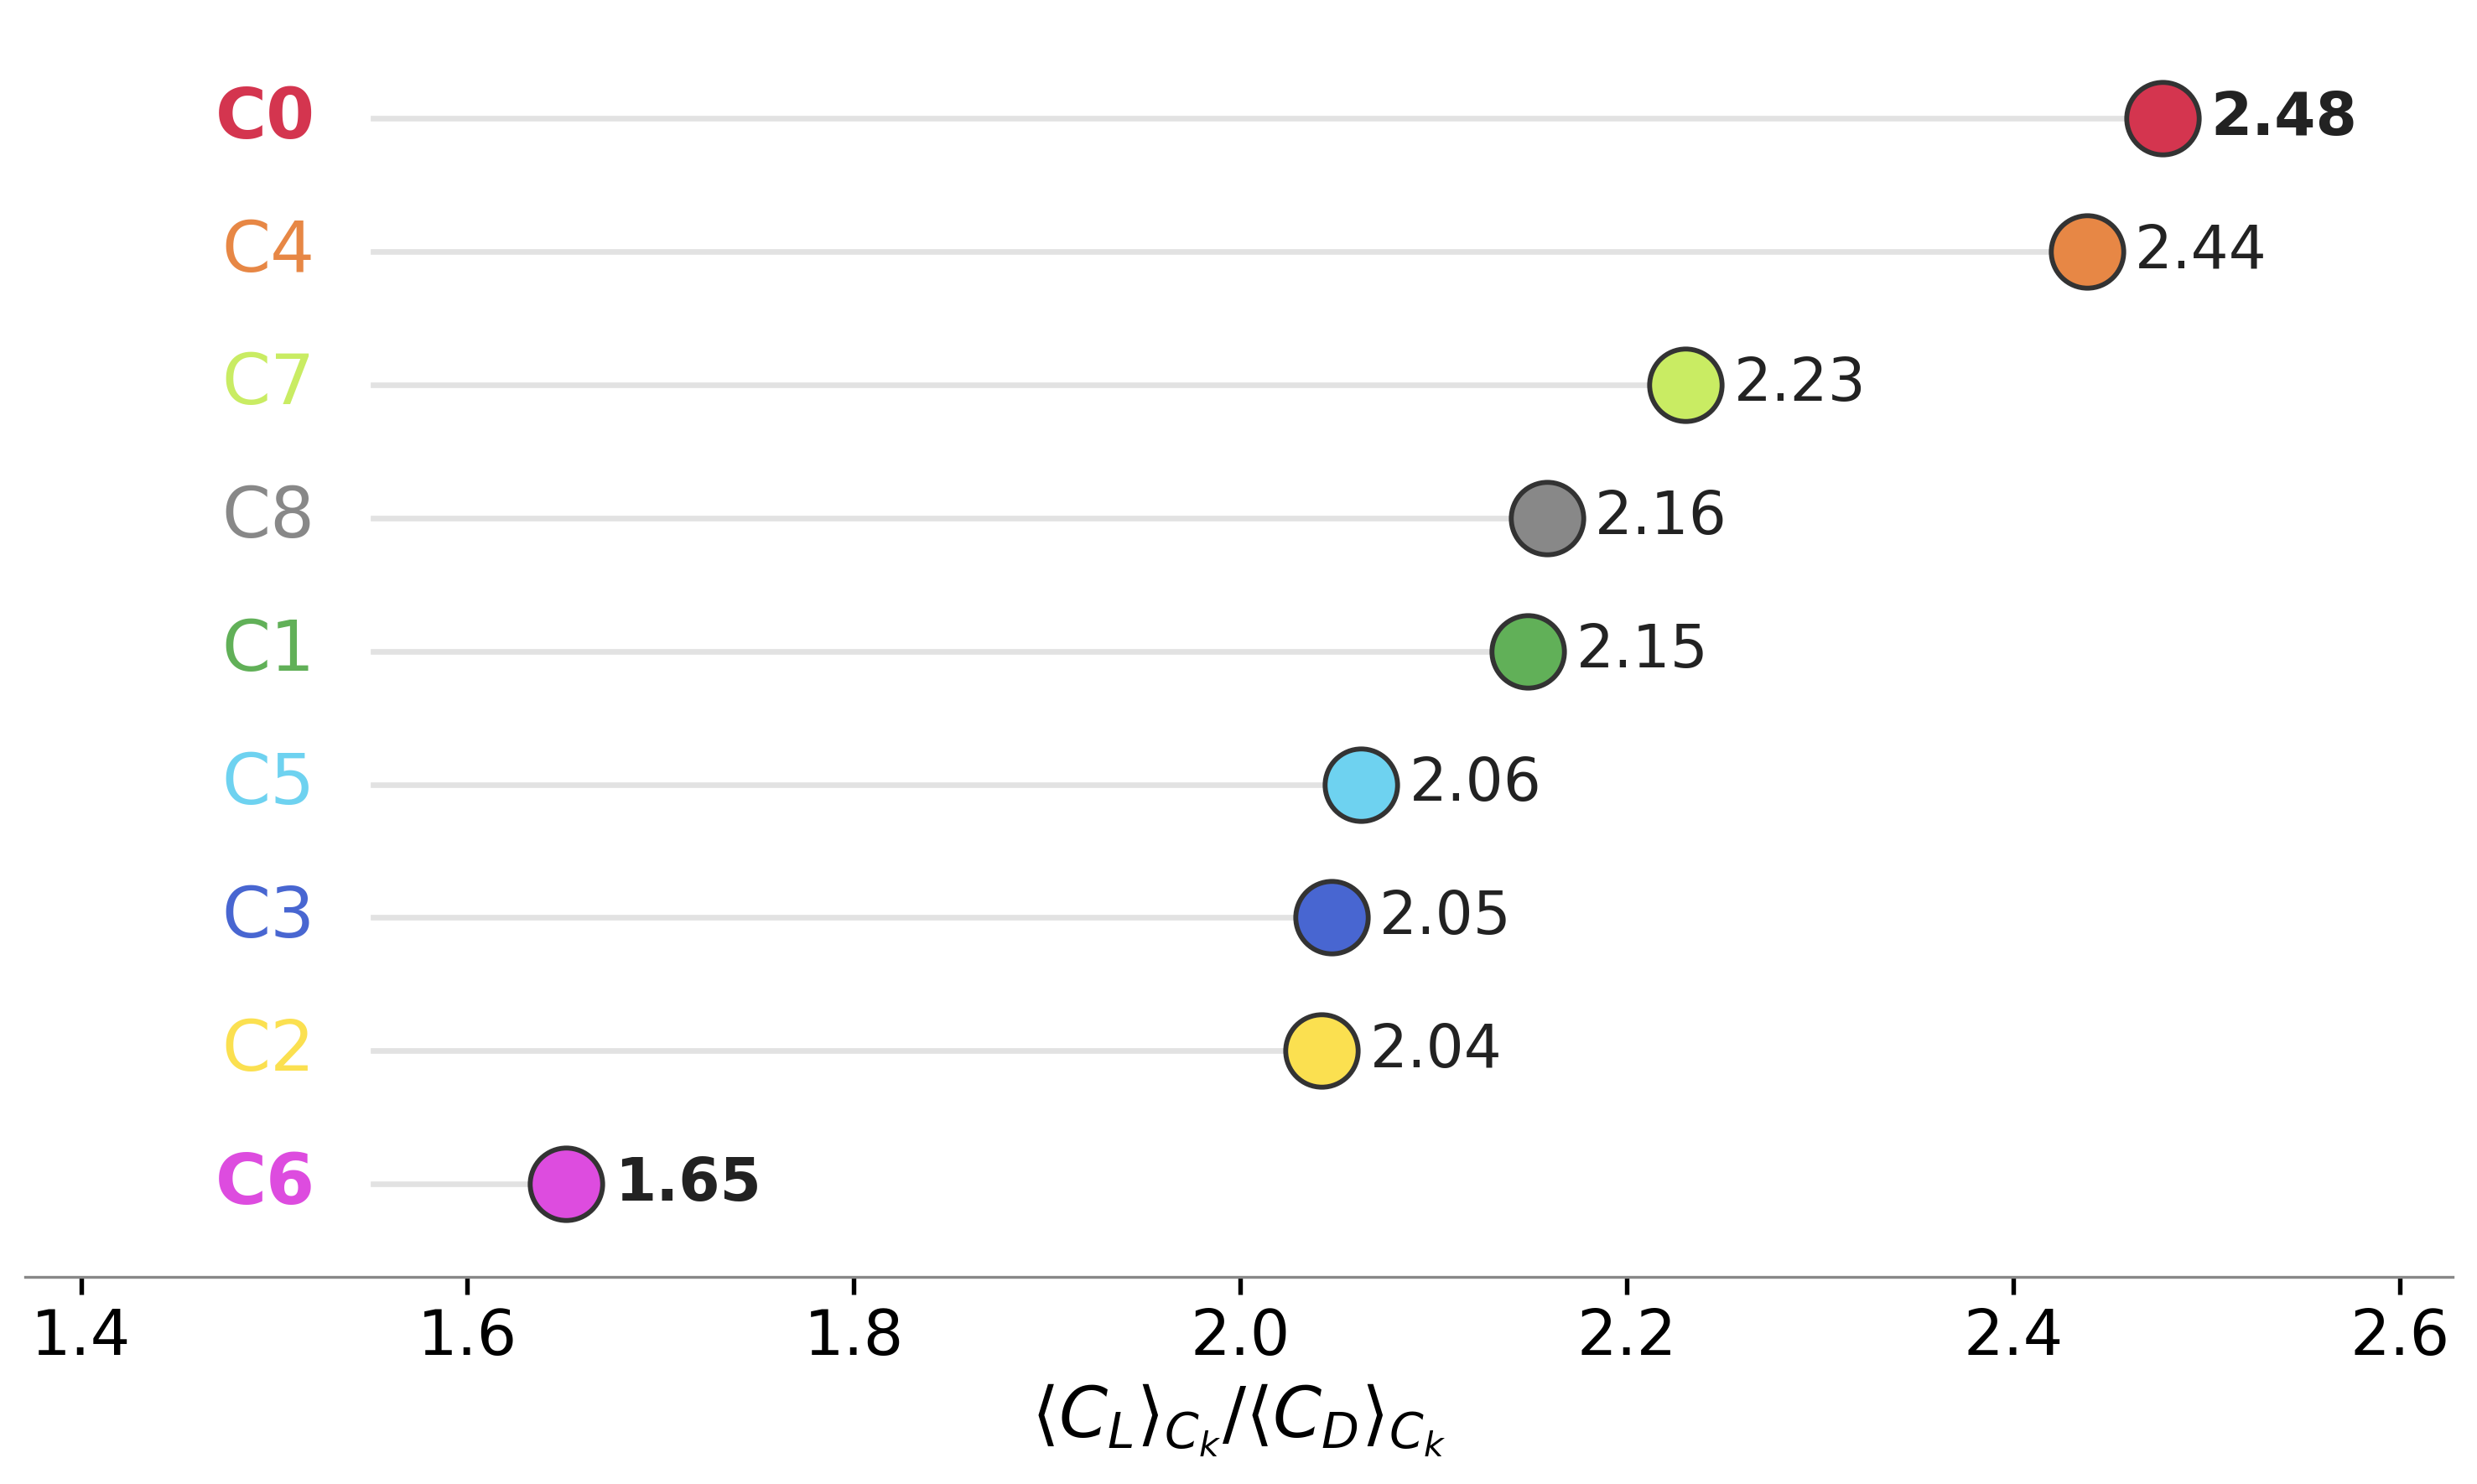

In [12]:
cluster_colors = {0:'#d4354f', 1:'#61b058', 2:'#fbe050', 3:'#4866d1', 4:'#e78745',
                  5:'#6ed2f0', 6:'#dd4cdf', 7:'#c9ec63', 8:'#888888'}

order = np.argsort(clcd_ratio_means)[::-1]
xmin = clcd_ratio_means.min() - 0.10
xmax = clcd_ratio_means.max() + 0.10

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

for row, k in enumerate(order):
    y = len(order) - 1 - row
    v = clcd_ratio_means[k]
    emph = k in (order[0], order[-1])

    ax.plot([xmin, v], [y, y], color="#e2e2e2", lw=1.6, zorder=1)
    ax.scatter(v, y, s=430, color=cluster_colors[k], edgecolor="#333333", linewidth=1.4, zorder=3)

    ax.text(xmin - 0.03, y, f"C{k}", ha="right", va="center", fontsize=20,
            fontweight="bold" if emph else "normal", color=cluster_colors[k])

    ax.text(v + 0.025, y, f"{v:.2f}", ha="left", va="center", fontsize=17,
            fontweight="bold" if emph else "normal", color="#222222")

ax.set_xlim(xmin - 0.18, xmax + 0.05)
ax.set_ylim(-0.7, len(order) - 0.3)
ax.set_yticks([])
ax.set_xlabel(r'$\langle C_L\rangle_{C_k}/\langle C_D\rangle_{C_k}$', fontsize=20)
ax.tick_params(axis="x", labelsize=18, width=1.3, length=5)

for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)

ax.spines["bottom"].set_color("#888888")

fig.tight_layout()
fig.savefig("cluster_aerodynamic_performance.png", dpi=500, bbox_inches="tight", facecolor="white")
plt.show()

# OL Forcing Case (Mechanism)

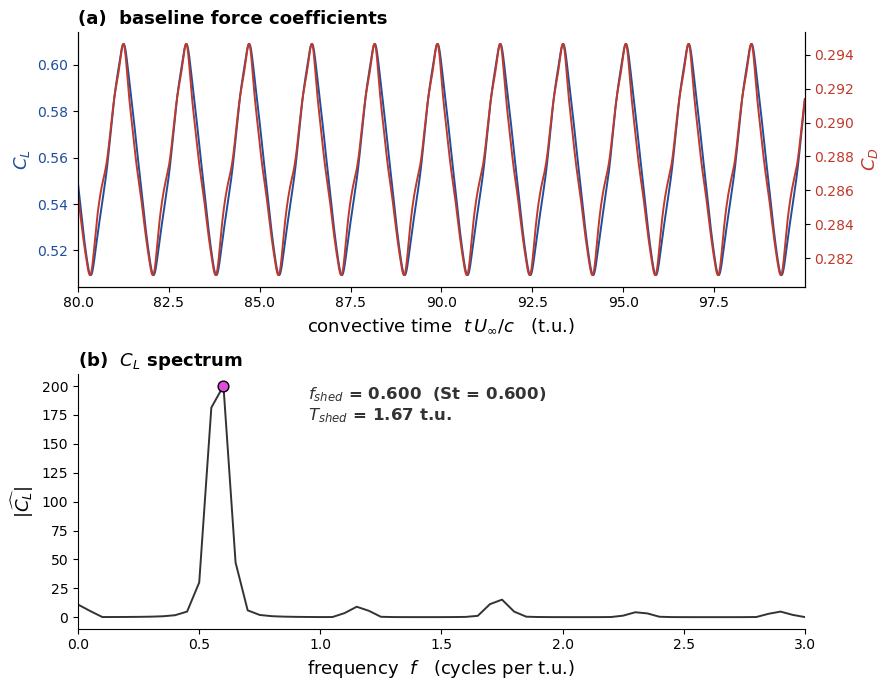

window: t = [80.0, 100.0] t.u.  (span 20.0 t.u.)
f_shed = 0.6000 cycles/t.u.   T_shed = 1.667 t.u.   St = 0.6000
1 t.u. = 1 convective time = 0.600 shedding periods
window spans 12.0 shedding cycles
saved timescales.npy  -> load this in every figure to convert t.u. -> shedding cycles


In [13]:
# Baseline aerodynamic sensor: CL/CD time series + FFT of CL -> shedding freq.
#   File cols (0-indexed): 0=iter, 1=CD, 2=CL   (sampled every CFD step, dt=DT)
#   Non-dim setup (ib.inp): U_inf = c = 1  ->  t.u. == convective time.
#   Saves timescales.npy  {dt, f_shed, T_shed, St, U_inf, c}  as the single
#   source of truth for converting every residence/probe axis to shedding cycles.

SENSOR_BL = "./data/baseline/rot_sensor_data.txt"   # same folder
DT     = 0.001          # t.u. per CFD step (from ib.inp)
U_INF  = 1.0            # non-dimensional freestream (ib.inp convention)
CHORD  = 1.0            # non-dimensional chord

# load
d   = np.loadtxt(SENSOR_BL)
it  = d[:, 0]
cd  = d[:, 1]
cl  = d[:, 2]
t   = it * DT                      # t.u. = convective time (U_inf = c = 1)

# FFT of CL (fundamental shedding frequency)
cl_ac = cl - cl.mean()             # remove DC / mean-lift offset
n     = len(cl_ac)
win   = np.hanning(n)              # window to suppress leakage
amp   = np.abs(np.fft.rfft(cl_ac * win))
freq  = np.fft.rfftfreq(n, d=DT)   # cycles per t.u.
kpk   = np.argmax(amp[1:]) + 1     # dominant peak (skip DC bin)
f_shed = float(freq[kpk])
T_shed = 1.0 / f_shed
St     = f_shed * CHORD / U_INF    # Strouhal (=f_shed since c=U=1)

# figure: (top) CL & CD vs time   (bottom) CL spectrum
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), facecolor='white')

# top: CL (left axis) + CD (right axis)
ax1.plot(t, cl, color='#1f4e9c', lw=1.4, label='$C_L$')
ax1.set_ylabel('$C_L$', color='#1f4e9c', fontsize=13)
ax1.tick_params(axis='y', labelcolor='#1f4e9c')
ax1b = ax1.twinx()
ax1b.plot(t, cd, color='#c0392b', lw=1.4, label='$C_D$')
ax1b.set_ylabel('$C_D$', color='#c0392b', fontsize=13)
ax1b.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_xlabel(r'convective time  $t\,U_\infty/c$   (t.u.)', fontsize=13)
ax1.set_xlim(t[0], t[-1])
ax1.set_title('(a)  baseline force coefficients', loc='left', fontsize=13, fontweight='bold')
for sp in ('top',): ax1.spines[sp].set_visible(False); ax1b.spines[sp].set_visible(False)

# bottom: CL power spectrum, peak marked
ax2.plot(freq, amp, color='#333333', lw=1.4)
ax2.scatter([f_shed], [amp[kpk]], s=60, facecolor='#dd4cdf',
            edgecolor='black', zorder=5)
ax2.annotate(f'$f_{{shed}}$ = {f_shed:.3f}  (St = {St:.3f})\n$T_{{shed}}$ = {T_shed:.2f} t.u.',
             xy=(f_shed, amp[kpk]), xytext=(f_shed + 0.35, amp[kpk]*0.85),
             fontsize=12, color='#333333', fontweight='bold')
ax2.set_xlim(0, min(3.0, freq[-1]))       # zoom to the low-frequency region
ax2.set_xlabel(r'frequency  $f$   (cycles per t.u.)', fontsize=13)
ax2.set_ylabel(r'$|\widehat{C_L}|$', fontsize=13)
ax2.set_title('(b)  $C_L$ spectrum', loc='left', fontsize=13, fontweight='bold')
for sp in ('top', 'right'): ax2.spines[sp].set_visible(False)


fig.tight_layout()
#fig.savefig('baseline_cl_cd_fft.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

# report + save single source of truth
span = t[-1] - t[0]
print(f"window: t = [{t[0]:.1f}, {t[-1]:.1f}] t.u.  (span {span:.1f} t.u.)")
print(f"f_shed = {f_shed:.4f} cycles/t.u.   T_shed = {T_shed:.3f} t.u.   St = {St:.4f}")
print(f"1 t.u. = 1 convective time = {1/T_shed:.3f} shedding periods")
print(f"window spans {span/T_shed:.1f} shedding cycles")

np.save('timescales.npy',
        {'dt': DT, 'U_inf': U_INF, 'c': CHORD,
         'f_shed': f_shed, 'T_shed': T_shed, 'St': St})

print("saved timescales.npy  -> load this in every figure to convert t.u. -> shedding cycles")

# Casuality probe at C0

## Timing sweep $s$

In [14]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import proj3d

PROBE_ROOT = "./data/c0_timing_probe/"
S_LIST = [500, 2750, 8000]
S_ALL = list(range(0, 8001, 250))
TARGET = 6
ROMAN = ['i', 'ii', 'iii']

DT_ITER = 0.001
ST_SHED = 0.6
T_SHED = 1.0 / ST_SHED

def iter_to_shed(s):
    return s * DT_ITER / T_SHED

BG_SPARSITY = 2.0
BG_ALPHA = 0.10
BG_SIZE = 1.4
CEN_SIZE = 46
CEN_LBL_FS = 17
STRIDE = 3
TRAJ_LW_ON = 2.8
TRAJ_LW_OFF = 2.0
DASH = (0, (5, 3))
PV_ELEV, PV_AZIM, PV_ZOOM = VIEW_ELEV, VIEW_AZIM, ZOOM
ROMAN_FS = 20

RUN_MIN = 4
LBL_UP = 1.7
LBL_DOWN = -1.7

plt.rcParams.update({'font.size': 13, 'axes.titlesize': 14, 'axes.labelsize': 13,
                     'xtick.labelsize': 11, 'ytick.labelsize': 11})

SMIN, SMAX = 0.0, iter_to_shed(8000)

bg_keep = (margin_ratio >= BG_SPARSITY) if (BG_SPARSITY and BG_SPARSITY > 0) else np.ones(len(labels_np), bool)
halo = [pe.withStroke(linewidth=2.0, foreground='white')]

In [15]:
def load_case(s):
    d = np.load(os.path.join(PROBE_ROOT, f"s_shift_{s:04d}", "results.npy"), allow_pickle=True).item()
    return (np.asarray(d['latent_hist'], dtype=np.float32),
            np.asarray(d['forcing_hist'], dtype=float),
            np.asarray(d['cluster_hist'], dtype=int))

s_vals, frac = [], []

for s in S_ALL:
    p = os.path.join(PROBE_ROOT, f"s_shift_{s:04d}", "results.npy")
    if not os.path.exists(p):
        continue

    d = np.load(p, allow_pickle=True).item()
    force = np.asarray(d['forcing_hist'], dtype=float)
    clu = np.asarray(d['cluster_hist'], dtype=int)

    obs = force != 0.0
    if obs.sum() == 0:
        continue

    s_vals.append(iter_to_shed(s))
    frac.append((clu[obs] == TARGET).mean() * 100)

s_vals = np.array(s_vals)
frac = np.array(frac)

curve_y_at = lambda s_sh: float(np.interp(s_sh, s_vals, frac))

def draw_card(ax, s):
    lat, force, clu = load_case(s)
    traj = reducer_3d.transform(lat)
    is_forced = force != 0.0

    for k in range(9):
        m = bg_keep & (labels_np == k)
        ax.scatter(emb_pts[m,0], emb_pts[m,1], emb_pts[m,2], s=BG_SIZE,
                   c=cluster_colors[k], alpha=BG_ALPHA, edgecolors='none', depthshade=False)

    ax.scatter(emb_cen[:,0], emb_cen[:,1], emb_cen[:,2], s=CEN_SIZE,
               c=[cluster_colors[k] for k in range(9)], marker='D',
               edgecolors='black', linewidths=1.1, depthshade=False, zorder=5)

    idx = np.arange(0, len(traj), STRIDE)
    tp, tc, tf = traj[idx], clu[idx], is_forced[idx]

    seg_on, col_on, seg_off, col_off = [], [], [], []

    for a in range(len(tp) - 1):
        col = cluster_colors[int(tc[a])]
        if tf[a + 1]:
            seg_on.append([tp[a], tp[a+1]])
            col_on.append(col)
        else:
            seg_off.append([tp[a], tp[a+1]])
            col_off.append(col)

    if seg_off:
        ax.add_collection3d(Line3DCollection(seg_off, colors=col_off,
                            linewidths=TRAJ_LW_OFF, linestyles=DASH, zorder=4))

    if seg_on:
        ax.add_collection3d(Line3DCollection(seg_on, colors=col_on,
                            linewidths=TRAJ_LW_ON, linestyles='solid', zorder=5))

    ax.scatter(tp[:,0], tp[:,1], tp[:,2], marker='o', s=12,
               c=[cluster_colors[int(k)] for k in tc], edgecolors='black',
               linewidths=0.3, depthshade=False, zorder=6)

    ax.scatter(*traj[0], marker='o', s=90, facecolors='none',
               edgecolors='black', linewidths=1.5, zorder=8)

    if is_forced.any():
        j = int(np.argmax(is_forced))
        ax.scatter(*traj[j], marker='o', s=120, facecolors='none',
                   edgecolors='black', linewidths=1.5, linestyle=':', zorder=8)

    ax.view_init(elev=PV_ELEV, azim=PV_AZIM)

    try:
        ax.set_box_aspect((np.ptp(emb_pts[:,0]), np.ptp(emb_pts[:,1]), np.ptp(emb_pts[:,2])))
    except Exception:
        pass

    for setlim, lo, hi in [
        (ax.set_xlim3d, emb_pts[:,0].min(), emb_pts[:,0].max()),
        (ax.set_ylim3d, emb_pts[:,1].min(), emb_pts[:,1].max()),
        (ax.set_zlim3d, emb_pts[:,2].min(), emb_pts[:,2].max()),
    ]:
        c = 0.5 * (lo + hi)
        r = 0.5 * (hi - lo) * PV_ZOOM
        setlim(c - r, c + r)

    ax.set_axis_off()
    return clu, is_forced

In [16]:
def label_centroids(ax):
    for k in range(9):
        x, y, _ = proj3d.proj_transform(emb_cen[k,0], emb_cen[k,1], emb_cen[k,2], ax.get_proj())
        ax.annotate(f'C{k}', xy=(x, y), xycoords='data', xytext=(0, 9),
                    textcoords='offset points', color=cluster_colors[k],
                    fontsize=CEN_LBL_FS, fontweight='bold', zorder=30,
                    annotation_clip=False, path_effects=halo)

def draw_bar(bx, clu, is_forced):
    bx.set_ylim(0, 1)
    bx.set_xlim(0, len(clu))

    for i, k in enumerate(clu):
        bx.add_patch(plt.Rectangle((i, 0), 1, 1, color=cluster_colors[int(k)], lw=0))

    runs, start = [], 0

    for i in range(1, len(clu) + 1):
        if i == len(clu) or clu[i] != clu[start]:
            runs.append((int(clu[start]), start, i - 1))
            start = i

    labeled = [r for r in runs if (r[2] - r[1] + 1) >= RUN_MIN]

    for n, (k, lo, hi) in enumerate(labeled):
        mid = 0.5 * (lo + hi + 1)
        up = (n % 2 == 0)
        yoff = LBL_UP if up else LBL_DOWN

        bx.annotate(f'C{k}', xy=(mid, 1.0 if up else 0.0), xytext=(mid, yoff),
                    textcoords='data', xycoords='data', color=cluster_colors[k],
                    fontsize=11, fontweight='bold', va='bottom' if up else 'top',
                    ha='center', arrowprops=dict(arrowstyle='-', color=cluster_colors[k], lw=0.9))

    if is_forced.any():
        j = int(np.argmax(is_forced))
        bx.plot([j, j], [-0.35, 1.35], color='black', lw=1.6, clip_on=False)
        bx.text(j, 2.7, 'pulse on', fontsize=10, ha='center', va='bottom', fontweight='bold')

    bx.set_yticks([])
    bx.set_xticks([0, len(clu)])
    bx.set_xticklabels(['IC', 'end'], fontsize=10)

    for sp in bx.spines.values():
        sp.set_visible(False)

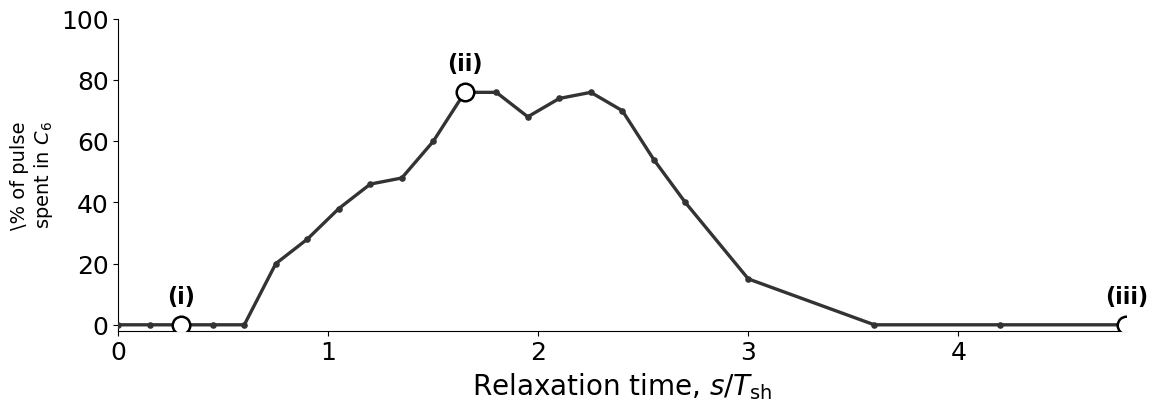

In [17]:
figA = plt.figure(figsize=(12, 4), facecolor='white')
axA = figA.add_axes([0.12, 0.16, 0.84, 0.78], facecolor='white')

axA.plot(s_vals, frac, '-', color='#333333', lw=2.4, zorder=3)
axA.scatter(s_vals, frac, s=14, color='#333333', zorder=4)

for r, s in zip(ROMAN, S_LIST):
    xx = iter_to_shed(s)
    yy = curve_y_at(xx)

    axA.scatter([xx], [yy], s=160, facecolors='white', edgecolors='black', linewidths=1.8, zorder=7)
    axA.annotate(f'({r})', xy=(xx, yy), xytext=(0, 12), textcoords='offset points',
                 ha='center', va='bottom', fontsize=16, fontweight='bold', zorder=8)

axA.set_xlabel(r'Relaxation time, $s/T_{\mathrm{sh}}$', fontsize=20)
axA.set_ylabel(r'\% of pulse' '\n' r'spent in $C_6$', fontsize=14)

axA.tick_params(axis='x', labelsize=18)
axA.tick_params(axis='y', labelsize=18)

axA.set_xlim(SMIN, SMAX)
axA.set_ylim(-2, 100)

for sp in ('top', 'right'):
    axA.spines[sp].set_visible(False)

#figA.savefig('probe_curve.png', dpi=500, facecolor='white', bbox_inches='tight')
plt.show()

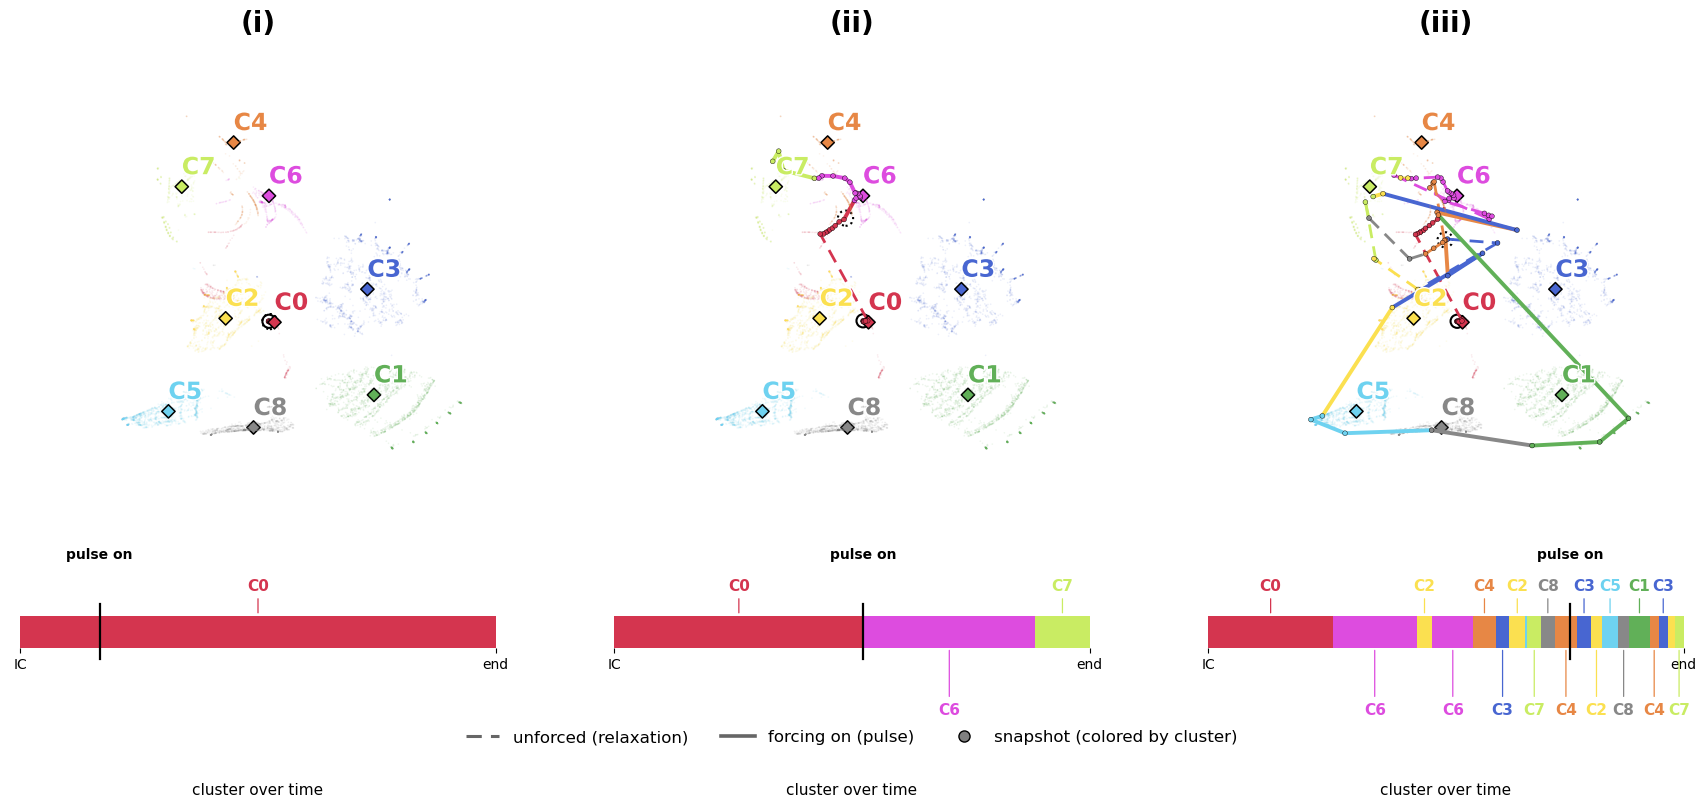

In [18]:
# FIGURE B : the three cards (standalone)
figB = plt.figure(figsize=(18, 8), facecolor='white')
CARD_X = [0.02, 0.35, 0.68]
CARD_W, CARD_Y, CARD_H = 0.30, 0.30, 0.62
BAR_Y,  BAR_H          = 0.16, 0.040

card_axes = []
for s, x in zip(S_LIST, CARD_X):
    ax = figB.add_axes([x, CARD_Y, CARD_W, CARD_H], projection='3d', facecolor='none')
    clu, is_forced = draw_card(ax, s)
    card_axes.append((ax, s, clu, is_forced, x))
figB.canvas.draw()
for (ax, s, clu, is_forced, x), r in zip(card_axes, ROMAN):
    label_centroids(ax)
    ax.set_title(f'({r})', fontsize=ROMAN_FS, fontweight='bold', pad=6)   # roman numeral only
    bx = figB.add_axes([x + 0.018, BAR_Y, CARD_W - 0.036, BAR_H])
    draw_bar(bx, clu, is_forced)
    bx.text(0.5, -4.2, 'cluster over time', transform=bx.transAxes,
            ha='center', va='top', fontsize=11)

figB.legend(handles=[
    Line2D([0],[0], color='0.4', lw=2.2, ls=DASH,    label='unforced (relaxation)'),
    Line2D([0],[0], color='0.4', lw=2.6, ls='solid', label='forcing on (pulse)'),
    Line2D([0],[0], marker='o', color='none', markerfacecolor='0.5',
           markeredgecolor='black', markersize=8, label='snapshot (colored by cluster)'),
], loc='lower center', ncol=3, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.02))

# figB.savefig('probe_cards.png', dpi=500, facecolor='white', bbox_inches='tight')
plt.show()

## Analysis for b*, amplitude sweep b

In [19]:
from pathlib import Path

ROOT = Path('./data/c0_amp_probe/')

DT = 0.001
T_SH = 1.667
DROP_CYCLES = 10
AMPS = [round(0.01*i, 3) for i in range(1, 11)]

signals = {}
cl_rms = []

for amp in AMPS:
    path = ROOT / f'amp_{amp:.3f}' / 'rot_sensor_data.txt'
    data = np.loadtxt(path, delimiter=',', skiprows=1)

    it = data[:, 0]
    cl = data[:, -1]

    t_sh = (it - it[0]) * DT / T_SH
    keep = t_sh >= DROP_CYCLES

    cl_mean = cl[keep].mean()
    cl_fluc = cl - cl_mean

    signals[amp] = (t_sh, cl_fluc)
    cl_rms.append(np.sqrt(np.mean(cl_fluc[keep]**2)))

cl_rms = np.array(cl_rms)

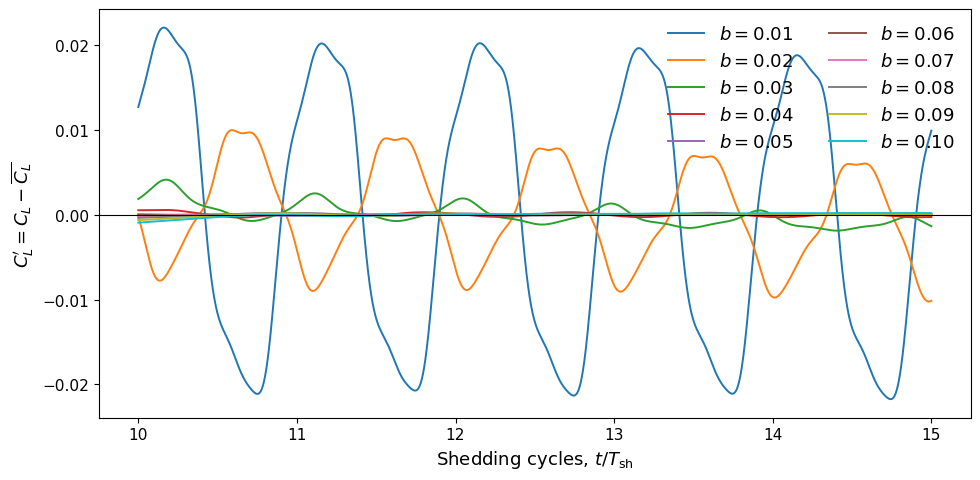

In [20]:
plt.figure(figsize=(10, 5))

for amp in AMPS:
    t_sh, cl_fluc = signals[amp]
    keep = t_sh >= DROP_CYCLES
    plt.plot(t_sh[keep], cl_fluc[keep], lw=1.4, label=fr'$b={amp:.2f}$')

plt.axhline(0, color='k', lw=0.8)
plt.xlabel(r'Shedding cycles, $t/T_{\mathrm{sh}}$')
plt.ylabel(r"$C_L' = C_L-\overline{C_L}$")
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

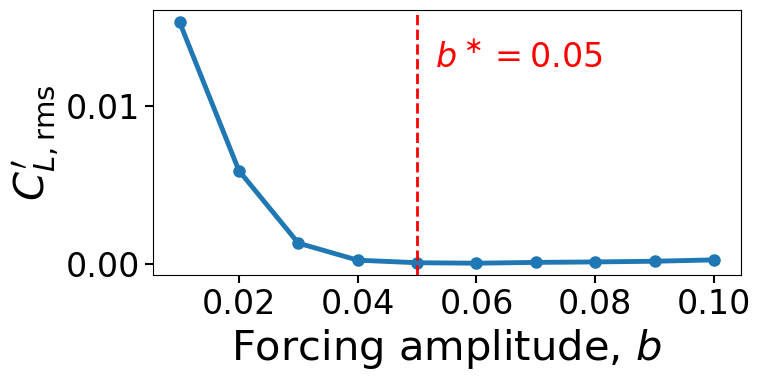

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(AMPS, cl_rms, 'o-', lw=3.5, ms=8)
ax.axvline(0.05, color='red', linestyle='--', lw=2)
ax.text(0.053, max(cl_rms)*0.92, r'$b^\ast \equal 0.05$', color='red', fontsize=24, va='top', ha='left')

ax.set_xlabel(r'Forcing amplitude, $b$', fontsize=30)
ax.set_ylabel(r"$C_{L,\mathrm{rms}}'$", fontsize=30)
ax.tick_params(axis='both', labelsize=24, width=1.5, length=6)

plt.tight_layout()
# plt.savefig('lift_fluctuation_vs_forcing_amplitude.png', dpi=500, bbox_inches='tight')
plt.show()

## Effect of release from $C_0$

In [22]:
PROBE_ROOT = "./data/c0_timing_probe"
S_SHIFT = 20_000

RUN_DIR = os.path.join(PROBE_ROOT, f"s_shift_{S_SHIFT:04d}")
RESULTS_PATH = os.path.join(RUN_DIR, "results.npy")
SNAP_DIR = os.path.join(RUN_DIR, "snapshots")

DT = 0.001
F_SH = 0.60
T_SH = 1.0 / F_SH

SHEDDING_FAMILY = {1, 2, 3, 5, 8}

data = np.load(RESULTS_PATH, allow_pickle=True).item()

latent = np.asarray(data["latent_hist"], dtype=np.float32)
forcing = np.asarray(data["forcing_hist"], dtype=float)
clusters = np.asarray(data["cluster_hist"], dtype=int)

print("keys:", data.keys())
print("latent_hist :", latent.shape)
print("forcing_hist:", forcing.shape)
print("cluster_hist:", clusters.shape)

print(f"\nT_sh = {T_SH:.4f} convective units")
print(f"1 T_sh = {T_SH / DT:.1f} CFD iterations")
print(f"s_shift = {S_SHIFT} iterations = {S_SHIFT*DT/T_SH:.2f} T_sh")

keys: dict_keys(['s', 'istart', 'F_ON', 'obs_len', 'iter_hist', 'forcing_hist', 'latent_hist', 'cluster_hist'])
latent_hist : (410, 8)
forcing_hist: (410,)
cluster_hist: (410,)

T_sh = 1.6667 convective units
1 T_sh = 1666.7 CFD iterations
s_shift = 20000 iterations = 12.00 T_sh


In [23]:
forced = np.abs(forcing) > 1e-12
forced_idx = np.flatnonzero(forced)

if len(forced_idx) == 0:
    pulse_on_idx = len(forcing)
    print("No pulse found in this trajectory.")
else:
    pulse_on_idx = int(forced_idx[0])

print("pulse-on array index:", pulse_on_idx)

if pulse_on_idx > 0:
    iter_per_sample = S_SHIFT / pulse_on_idx
    print(f"inferred CFD iterations per stored sample = {iter_per_sample:.2f}")
else:
    raise RuntimeError("Pulse appears to start immediately; check forcing_hist.")

pulse-on array index: 400
inferred CFD iterations per stored sample = 50.00


In [24]:
import glob, re
rel_iter = np.arange(len(clusters)) * iter_per_sample
t_conv = rel_iter * DT
t_sh = t_conv / T_SH
print(f"pulse starts at t/T_sh = {t_sh[pulse_on_idx]:.3f}")


snap_files = sorted(glob.glob(os.path.join(SNAP_DIR, "snapshot_*.png")))
snap_iters = np.array([
    int(re.search(r"snapshot_(\d+)\.png$", f).group(1))
    for f in snap_files
])

print("number of snapshots:", len(snap_iters))
print("number of cluster labels:", len(clusters))

pulse starts at t/T_sh = 12.000
number of snapshots: 410
number of cluster labels: 410


In [25]:
# Plot settings
T_MAX = 7.0   # show only first 7 shedding cycles

cluster_colors = {0:'#d4354f', 1:'#61b058', 2:'#fbe050', 3:'#4866d1', 4:'#e78745',
                  5:'#6ed2f0', 6:'#dd4cdf', 7:'#c9ec63', 8:'#888888'}

# Release-only part, trimmed to 7 cycles
clu_A = clusters[:pulse_on_idx]
t_A   = t_sh[:pulse_on_idx]

mask = t_A <= T_MAX
t_plot = t_A[mask]
clu_plot = clu_A[mask]

# If needed, make sure the last point reaches exactly T_MAX
if t_plot[-1] < T_MAX:
    t_plot = np.append(t_plot, T_MAX)
    clu_plot = np.append(clu_plot, clu_plot[-1])

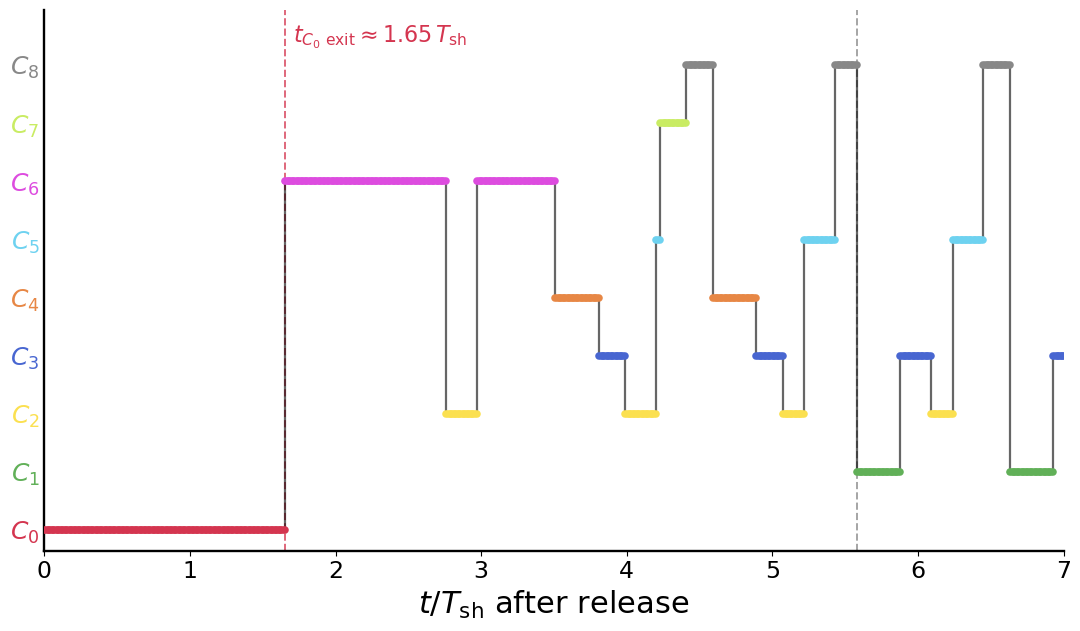

In [26]:
# Important times
t_c0_exit          = 1.65
t_baseline_return  = 5.58 # 4.90 starts heading to baseline and by 5.58 is in the baeleine!


# Plot
fig, ax = plt.subplots(figsize=(11, 6.5))

# Light black step line
ax.step(t_plot, clu_plot, where="post", color="black", lw=1.6, alpha=0.6, zorder=1)

# Overlay colored horizontal run segments
for i in range(len(t_plot) - 1):
    x0, x1 = t_plot[i], t_plot[i + 1]
    y = clu_plot[i]
    ax.plot([x0, x1], [y, y], color=cluster_colors[int(y)],
        lw=5.5, solid_capstyle="round", zorder=3)

# Optional: colored sample dots (small)
for k in range(9):
    kk = clu_plot[:-1] == k
    if np.any(kk):
        ax.scatter(t_plot[:-1][kk], clu_plot[:-1][kk],
            s=18, color=cluster_colors[k], edgecolor="none", zorder=4)

# Light guide lines
ax.axvline(t_c0_exit, color=cluster_colors[0], ls="--", lw=1.4, alpha=0.75, zorder=0)
ax.axvline(t_baseline_return, color=cluster_colors[8], ls="--", lw=1.4, alpha=0.75, zorder=0)

# Annotation: only C0 exit
ax.text(t_c0_exit + 0.06, 8.72,
    r"$t_{C_0\ \mathrm{exit}} \approx 1.65\,T_{\mathrm{sh}}$",
    color=cluster_colors[0], fontsize=16, va="top")

# Axes
ax.set_xlabel(r"$t/T_{\mathrm{sh}}$ after release", fontsize=22)
# ax.set_ylabel("macrostate", fontsize=22)

ax.set_yticks(range(9))
ax.set_yticklabels([rf"$C_{k}$" for k in range(9)], fontsize=18)

# Color y tick labels
for k, tick in enumerate(ax.get_yticklabels()):
    tick.set_color(cluster_colors[k])

ax.set_xlim(0, T_MAX)
ax.set_ylim(-0.35, 8.95)

ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', length=0)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.7)
ax.spines["bottom"].set_linewidth(1.7)

plt.tight_layout()
#fig.savefig("cluster_association_release.png", dpi=500, bbox_inches="tight", facecolor="white")
plt.show()

In [27]:
S_CASES = [4000, 5000]

for s_iter in S_CASES:
    run_dir = os.path.join(PROBE_ROOT, f"s_shift_{s_iter:04d}")
    data = np.load(os.path.join(run_dir, "results.npy"), allow_pickle=True).item()

    force = np.asarray(data["forcing_hist"], dtype=float)
    clu = np.asarray(data["cluster_hist"], dtype=int)

    forced_idx = np.flatnonzero(np.abs(force) > 1e-12)
    i_on = forced_idx[0]

    runs_case = []
    start = 0

    for i in range(1, len(clu) + 1):
        if i == len(clu) or clu[i] != clu[start]:
            runs_case.append((int(clu[start]), start, i))
            start = i

    print(f"\n--- s/T_sh = {s_iter*DT/T_SH:.2f} ---")
    print(f"pulse begins at sample {i_on}\n")

    for k, i0, i1 in runs_case:
        t0 = i0 * iter_per_sample * DT / T_SH
        t1 = i1 * iter_per_sample * DT / T_SH

        phase = "OFF" if i1 <= i_on else ("ON" if i0 >= i_on else "CROSSES")

        print(
            f"{phase:7s}   C{k} : "
            f"{t0:5.2f} -> {t1:5.2f} T_sh"
        )


--- s/T_sh = 2.40 ---
pulse begins at sample 80

OFF       C0 :  0.00 ->  1.65 T_sh
CROSSES   C6 :  1.65 ->  3.45 T_sh
ON        C4 :  3.45 ->  3.90 T_sh

--- s/T_sh = 3.00 ---
pulse begins at sample 100

OFF       C0 :  0.00 ->  1.65 T_sh
OFF       C6 :  1.65 ->  2.76 T_sh
OFF       C2 :  2.76 ->  2.97 T_sh
CROSSES   C6 :  2.97 ->  3.54 T_sh
ON        C4 :  3.54 ->  3.84 T_sh
ON        C3 :  3.84 ->  3.99 T_sh
ON        C2 :  3.99 ->  4.11 T_sh
ON        C7 :  4.11 ->  4.32 T_sh
ON        C0 :  4.32 ->  6.60 T_sh


In [28]:
PROBE_ROOT = "./data/c0_timing_probe"

# Long release-only reference: 12 T_sh = 20000 iterations
RELEASE_RUN = os.path.join(PROBE_ROOT, "s_shift_20000", "results.npy")

# Re-actuation at s/T_sh = 3.0: 5000 iterations
REACT_RUN = os.path.join(PROBE_ROOT, "s_shift_5000", "results.npy")

DT = 0.001
F_SH = 0.60
T_SH = 1.0 / F_SH
T_MAX = 6.6


release_data = np.load(RELEASE_RUN, allow_pickle=True).item()
react_data   = np.load(REACT_RUN, allow_pickle=True).item()

clu_release = np.asarray(release_data["cluster_hist"], dtype=int)
f_release   = np.asarray(release_data["forcing_hist"], dtype=float)

clu_react = np.asarray(react_data["cluster_hist"], dtype=int)
f_react   = np.asarray(react_data["forcing_hist"], dtype=float)


# Re-actuation case: pulse starts after 5000 CFD iterations
react_on_idx = np.flatnonzero(np.abs(f_react) > 1e-12)[0]
iter_per_sample = 5000 / react_on_idx

print(f"iterations per stored sample = {iter_per_sample:.1f}")

t_release = np.arange(len(clu_release)) * iter_per_sample * DT / T_SH
t_react   = np.arange(len(clu_react))   * iter_per_sample * DT / T_SH

print(f"pulse begins at t/T_sh = {t_react[react_on_idx]:.2f}")

iterations per stored sample = 50.0
pulse begins at t/T_sh = 3.00


In [29]:
# Exact state timelines from saved CFD trajectories
dt_sh = iter_per_sample * DT / T_SH

def make_segments(labels, t_start, t_end):
    """Convert stored cluster labels into exact run-length segments."""
    labels = np.asarray(labels, dtype=int)

    segments = []
    i0 = 0

    for i in range(1, len(labels) + 1):
        if i == len(labels) or labels[i] != labels[i0]:

            seg_start = i0 * dt_sh
            seg_end   = i  * dt_sh

            # Clip to requested plotting interval
            a = max(seg_start, t_start)
            b = min(seg_end,   t_end)

            if b > a:
                segments.append((int(labels[i0]), a, b))

            i0 = i

    return segments


split_t = 3.0

# End of the newly extended re-actuated trajectory
xmax = len(clu_react) * dt_sh

# T14:
# The common trunk and upper unforced branch come directly from
# the SAME release-only trajectory used in panel (b).
trunk = make_segments(clu_release, 0.0, split_t)
top_branch = make_segments(clu_release, split_t, xmax)

# T15:
# Lower branch comes directly from the newly extended s=5000 run.
# This now shows what happens for ~2 additional shedding cycles
# after C0 is recaptured under b=0.05.
bottom_branch = make_segments(clu_react, split_t, xmax)

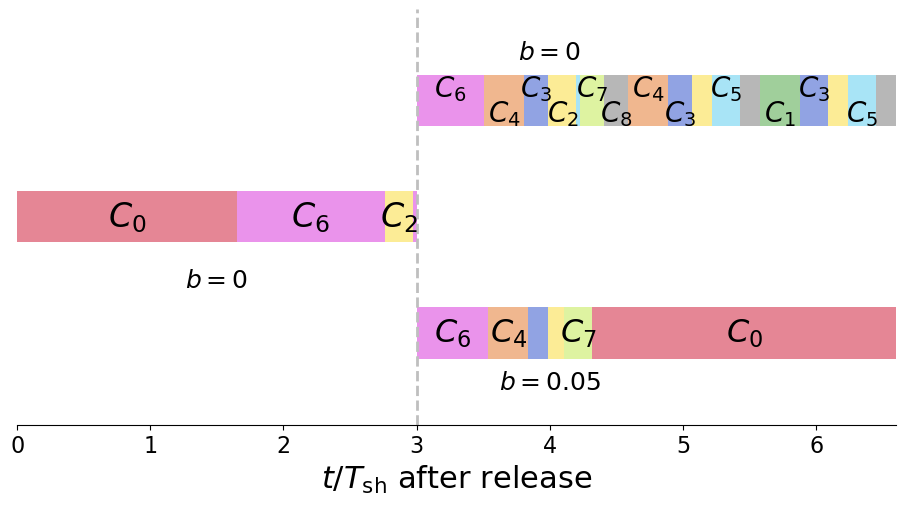

In [30]:
from matplotlib.patches import Rectangle

# Plot settings
y_trunk = 0.0
y_top   = 0.95
y_bot   = -0.95
bar_h = 0.42


fig, ax = plt.subplots(figsize=(9.25, 5.25))
def draw_segments(ax, segs, y, height=0.42, label_fs=22, stagger=False):
    """Draw colored horizontal state segments."""
    label_count = 0

    for state, t0, t1 in segs:
        w = t1 - t0

        rect = Rectangle(
            (t0, y - height/2), w, height,
            facecolor=cluster_colors[state],
            edgecolor='none',
            alpha=0.60
        )
        ax.add_patch(rect)

        if w >= 0.16:

            # Stagger labels only when requested (useful for crowded top branch)
            y_text = y
            if stagger:
                y_text = y + (0.10 if label_count % 2 == 0 else -0.10)

            ax.text(
                (t0 + t1) / 2, y_text,
                rf"$C_{state}$",
                ha="center", va="center",
                fontsize=label_fs,
                color="black"
            )

            label_count += 1

# Draw main trunk and branches
draw_segments(ax, trunk,         y_trunk, height=bar_h, label_fs=24)
draw_segments(ax, top_branch,    y_top,   height=bar_h, label_fs=20, stagger=True)
draw_segments(ax, bottom_branch, y_bot,   height=bar_h, label_fs=23)

# Split line
ax.axvline(split_t, color="0.75", ls="--", lw=2)


# Branch labels
ax.text(
    1.50, y_trunk - 0.42,
    r"$b = 0$",
    ha="center", va="top",
    fontsize=18
)

ax.text(
    4.0, y_top + 0.30,
    r"$b=0$",
    ha="center", va="bottom",
    fontsize=18
)

ax.text(
    4.0, y_bot - 0.30,
    r"$b=0.05$",
    ha="center", va="top",
    fontsize=18
)

# Axes formatting
ax.set_xlim(0, xmax)
ax.set_ylim(-1.7, 1.7)

ax.set_xlabel(r"$t/T_{\mathrm{sh}}$ after release", fontsize=22)

ax.set_yticks([])
ax.set_ylabel("")

ax.tick_params(axis='x', labelsize=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
#plt.savefig('forcing_effect.png', dpi=500, bbox_inches='tight')
plt.show()

# $C_6$ Ensamble Analysis (Residence and Dwell time & Transition matrix)

In [31]:
from itertools import groupby
from functions import load_file

# the 10 top C6 escape laws (same mechanism: periodic relaxation forcing)
sim_paths = [
    "./data/top_c6_runs/wandering-sweep-64/snapshots/",
    "./data/top_c6_runs/charmed-sweep-49/snapshots/",
    "./data/top_c6_runs/quiet-sweep-35/snapshots/",
    "./data/top_c6_runs/mild-sweep-66/snapshots/",
    "./data/top_c6_runs/iconic-sweep-76/snapshots/",
    "./data/top_c6_runs/generous-sweep-65/snapshots/",
    "./data/top_c6_runs/happy-sweep-32/snapshots/",
    "./data/top_c6_runs/worthy-sweep-43/snapshots/",
    "./data/top_c6_runs/apricot-sweep-24/snapshots/",
    "./data/top_c6_runs/fiery-sweep-73/snapshots/",
    "./data/top_c6_runs/proud-sweep-74/snapshots/",
    "./data/top_c6_runs/cosmic-sweep-58/snapshots/",
    "./data/top_c6_runs/vital-sweep-42/snapshots/",
    "./data/top_c6_runs/dainty-sweep-78/snapshots/",
]

In [32]:
idx = np.arange(80_000, 100_000, 50)
K   = 9
dt_snapshot = 50 * 0.001          # 0.05 t.u. per snapshot

# encode each run, assign each snapshot to nearest centroid
all_runs_assignments = []
for sim_path in sim_paths:
    run_assignments = []
    for value in idx:
        image_path = os.path.join(sim_path, f"snapshot_{value:06d}.png")
        if not os.path.exists(image_path):
            continue
        processed_image = (
            torch.tensor(load_file(image_path), dtype=torch.float32) / 255.0
        ).permute(2, 0, 1).unsqueeze(0)
        mean = model.encode(processed_image)
        dist_ = torch.sum((mean - centroids_d8_k9) ** 2, axis=1)
        run_assignments.append(torch.argmin(dist_).item())
    all_runs_assignments.append(run_assignments)

# transition matrix (pooled, never crossing run boundaries)
transition_matrix = np.zeros((K, K))
for run_assignments in all_runs_assignments:
    for i in range(len(run_assignments) - 1):
        ci, cj = run_assignments[i], run_assignments[i + 1]
        if ci != cj:
            transition_matrix[ci, cj] += 1
row_sums = transition_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
transition_prob = transition_matrix / row_sums

# mean residence per visit
residence_times = {k: [] for k in range(K)}
for run_assignments in all_runs_assignments:
    for cluster_id, group in groupby(run_assignments):
        count = sum(1 for _ in group)
        residence_times[cluster_id].append(count * dt_snapshot)
mean_residence = {k: (np.mean(v) if v else 0.0) for k, v in residence_times.items()}

# conditional dwell T[i->j] = mean dwell in j given arrival from i
runs_list_per_run = []
for run_assignments in all_runs_assignments:
    runs_list = []
    for cluster_id, group in groupby(run_assignments):
        count = sum(1 for _ in group)
        runs_list.append((cluster_id, count * dt_snapshot))
    runs_list_per_run.append(runs_list)

conditional_dwell = {i: {j: [] for j in range(K)} for i in range(K)}
for runs_list in runs_list_per_run:
    for r in range(1, len(runs_list)):
        i, _    = runs_list[r - 1]
        j, dwell = runs_list[r]
        if i != j:
            conditional_dwell[i][j].append(dwell)

T_conditional = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        if conditional_dwell[i][j]:
            T_conditional[i][j] = np.mean(conditional_dwell[i][j])

# quick sanity print
print("mean residence (t.u.):")
for k in range(K):
    print(f"  C{k}: {mean_residence[k]:.3f}")
print(f"\nencoded {sum(len(r) for r in all_runs_assignments)} snapshots "
      f"across {len(all_runs_assignments)} runs")

/opt/anaconda3/envs/torch_env/lib/python3.10/site-packages/torch/nn/modules/conv.py:455: UserWarning:

Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1742433317015/work/aten/src/ATen/native/Convolution.cpp:1032.)



mean residence (t.u.):
  C0: 1.730
  C1: 0.354
  C2: 0.282
  C3: 0.306
  C4: 0.328
  C5: 0.259
  C6: 1.247
  C7: 0.405
  C8: 0.242

encoded 5600 snapshots across 14 runs


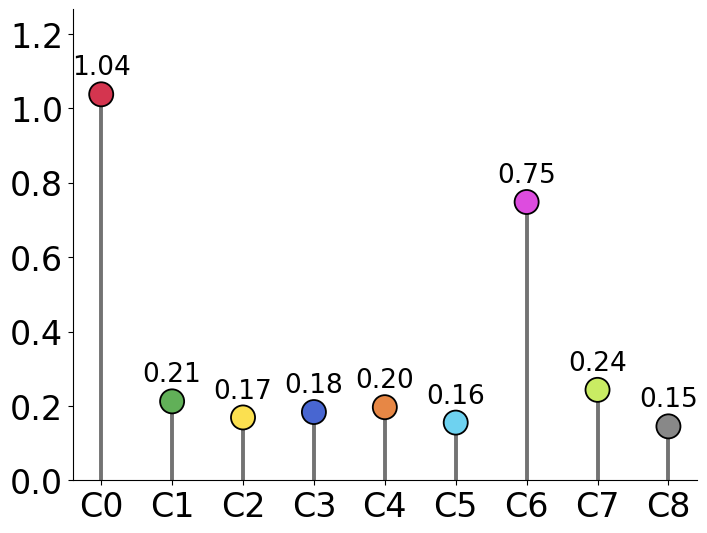

In [33]:
# C6 ESCAPE LAW — four panels saved INDIVIDUALLY.
#   (a) residence  (b) transition matrix  (c) representative forcing law
#   (d) conditional-dwell matrix  +  edge list export for the graph.
#   Times shown in SHEDDING CYCLES (primary) using T_shed from timescales.npy.

from matplotlib.colors import LinearSegmentedColormap, Normalize


OUT = "C6_law_results"; os.makedirs(OUT, exist_ok=True)
REP_RUN_DIR = "./data/top_c6_runs/worthy-sweep-43"
REP_SNAPS   = os.path.join(REP_RUN_DIR, "snapshots")
DT_ITER = 0.001
K = 9
ORDER  = [1, 2, 3, 5, 8, 0, 4, 6, 7]      # disc | C0 | branch
olabel = [f'C{k}' for k in ORDER]
PFLOOR = 0.20
N_MIN  = 10

# shedding timescale (single source of truth) 
ts = np.load('timescales.npy', allow_pickle=True).item()
T_SHED = ts['T_shed']                      # 1.667 t.u.
tu2cyc = lambda x: x / T_SHED              # t.u. -> shedding cycles

FS_LBL, FS_TICK, FS_TITLE, FS_NUM = 20, 24, 20, 19   # bumped-up font sizes

# (a) RESIDENCE
fig, ax = plt.subplots(figsize=(7.5, 5.6), facecolor='white')
ks   = list(range(K))
vals = [tu2cyc(mean_residence[k]) for k in ks]        # <- shedding cycles
_, stem, _ = ax.stem(ks, vals, basefmt=' ')
plt.setp(stem, color='0.45', linewidth=2.8)
ax.scatter(ks, vals, s=300, c=[cluster_colors[k] for k in ks],
           edgecolors='black', linewidths=1.3, zorder=5)

# number annotations above each circle.
# LBL_LIFT controls how far ABOVE the dot the number sits, as a fraction of the
# tallest bar. was 0.02 (numbers sat on the circle); raise it to push them up.
LBL_LIFT = 0.035                                       # <<< how far up the numbers sit
for k, v in zip(ks, vals):
    ax.text(k, v + LBL_LIFT*max(vals), f'{v:.2f}',
            ha='center', va='bottom', fontsize=FS_NUM)

ax.set_xticks(ks); ax.set_xticklabels([f'C{k}' for k in ks], fontsize=FS_TICK)
ax.tick_params(axis='y', labelsize=FS_TICK)
#ax.set_ylabel(r'$\tau_k$  (shedding cycles)', fontsize=FS_LBL)   # <<< shortened y-label
ax.set_ylim(0, max(vals) * 1.22)                       # a touch more headroom for lifted labels
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
fig.tight_layout(); 

#fig.savefig(f'{OUT}/a_residence.png', dpi=300, facecolor='white', bbox_inches='tight'); 

plt.show()

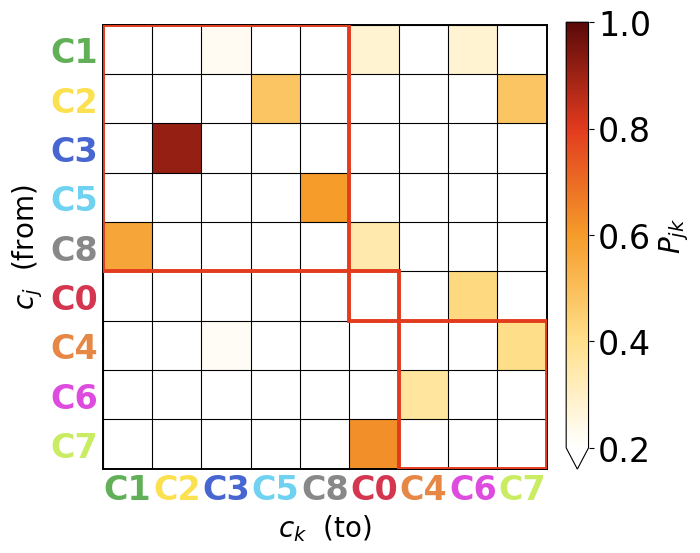

In [34]:
from matplotlib.patches import Rectangle
#(b) TRANSITION MATRIX
fig, ax = plt.subplots(figsize=(7.0, 6.2), facecolor='white')
P = transition_prob[np.ix_(ORDER, ORDER)]
hot = LinearSegmentedColormap.from_list('hot_w', ['white', '#ffe08a', '#f59c2a', '#e23b1e', '#5a0a0a'])
im = ax.imshow(P, cmap=hot, norm=Normalize(vmin=PFLOOR, vmax=1.0), origin='upper')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(olabel, fontsize=FS_TICK); ax.set_yticklabels(olabel, fontsize=FS_TICK)
for t, k in zip(ax.get_xticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
for t, k in zip(ax.get_yticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
ax.set_xticks(np.arange(-.5, K, 1), minor=True); ax.set_yticks(np.arange(-.5, K, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.8); ax.tick_params(which='both', length=0)
for sp in ax.spines.values(): sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.4)
for lo, hi in [(-.5, 4.5), (4.5, 5.5), (5.5, 8.5)]:
    ax.add_patch(Rectangle((lo, lo), hi-lo, hi-lo, fill=False, edgecolor='#e23b1e', linewidth=2.8, zorder=10))
ax.set_xlabel(r'$c_k$  (to)', fontsize=FS_LBL); ax.set_ylabel(r'$c_j$  (from)', fontsize=FS_LBL)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, extend='min')
cb.set_label(r'$P_{jk}$', fontsize=FS_LBL); cb.ax.tick_params(labelsize=FS_TICK)
fig.tight_layout(); 

#fig.savefig(f'{OUT}/b_transition.png', dpi=300, facecolor='white', bbox_inches='tight');
plt.show()

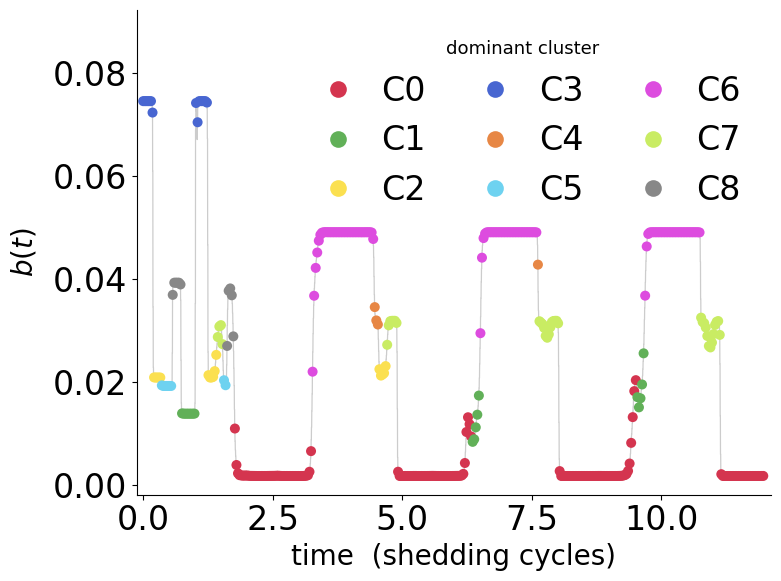

In [35]:
#(c) REPRESENTATIVE FORCING LAW
it, up = [], []
with open(os.path.join(REP_RUN_DIR, "rbf_forcing.txt")) as f:
    next(f)
    for line in f:
        p = line.strip().split(',')
        if len(p) >= 2: it.append(int(p[0])); up.append(float(p[1]))
it = np.array(it); up = np.array(up)
t_cyc = tu2cyc((it - it[0]) * DT_ITER)     # <<< elapsed cycles from window start (0-based)
dom = np.full(len(it), -1, dtype=int)
model.eval()
with torch.no_grad():
    for n, value in enumerate(it):
        ip = os.path.join(REP_SNAPS, f"snapshot_{int(value):06d}.png")
        if not os.path.exists(ip): continue
        img = (torch.tensor(load_file(ip), dtype=torch.float32)/255.0).permute(2,0,1).unsqueeze(0)
        z = model.encode(img)
        dom[n] = int(torch.argmin(torch.sum((z - centroids_d8_k9)**2, axis=1)).item())
fig, ax = plt.subplots(figsize=(8, 6.0), facecolor='white')
ax.plot(t_cyc, up, color='0.8', lw=0.9, zorder=1)
good = dom >= 0
ax.scatter(t_cyc[good], up[good], s=52, c=[cluster_colors[k] for k in dom[good]], edgecolors='none', zorder=2)
ax.set_xlabel('time  (shedding cycles)', fontsize=FS_LBL)
ax.set_ylabel(r'$b(t)$', fontsize=FS_LBL, labelpad=10)   # <<< y-label -> b(t)
ax.tick_params(labelsize=FS_TICK); ax.margins(x=0.01)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

# headroom so the 2-row legend clears the curve
ax.set_ylim(top=ax.get_ylim()[1] * 1.18)                 # <<< lift the top so legend doesn't overlap

visited = sorted(set(dom[good].tolist()))
ncol = 3                                                  # <<< 3 per row -> 3+3 layout (was ncol=2)
ax.legend(handles=[Line2D([0],[0], marker='o', color='none', markerfacecolor=cluster_colors[k],
                          markeredgecolor='none', markersize=12, label=f'C{k}') for k in visited],
          loc='upper right', fontsize=FS_TICK, ncol=ncol, frameon=False,
          title='dominant cluster', columnspacing=1.1, handletextpad=0.3)
fig.tight_layout();

# fig.savefig(f'{OUT}/c_forcing_law.png', dpi=300, facecolor='white', bbox_inches='tight');
plt.show()

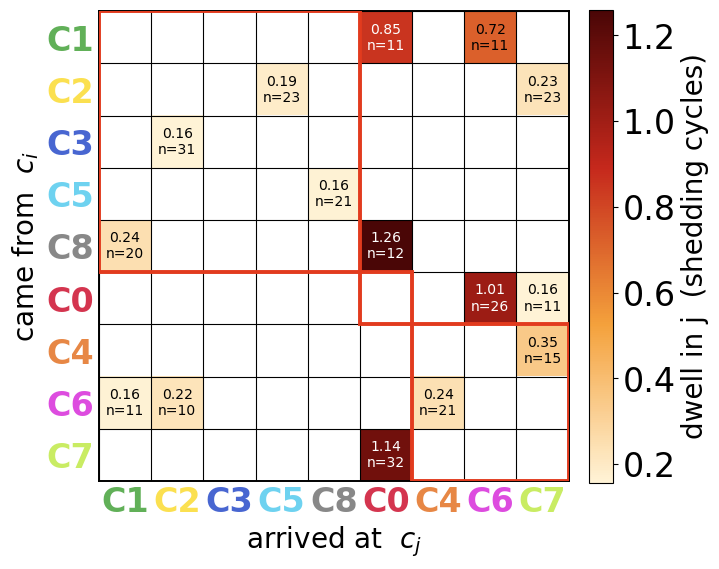

edge          P(width)  dwell_cyc(color)     n
C3->C2           0.912             0.157    31
C7->C0           0.627             1.143    32
C5->C8           0.600             0.161    21
C8->C1           0.571             0.245    20
C2->C5           0.479             0.189    23
C2->C7           0.479             0.227    23
C0->C6           0.419             1.014    26
C4->C7           0.405             0.346    15
C6->C4           0.368             0.243    21
C8->C0           0.343             1.260    12
C1->C0           0.275             0.851    11
C1->C6           0.275             0.720    11
C6->C1           0.193             0.164    11
C0->C7           0.177             0.161    11
C6->C2           0.175             0.222    10

saved 4 panels + edge_list.csv to ./C6_law_results/


In [36]:
#(d) CONDITIONAL DWELL MATRIX
# T[i->j] = mean dwell in j given arrival from i, shown in SHEDDING CYCLES, n>=N_MIN
Tcd = np.full((K, K), np.nan)
for i in range(K):
    for j in range(K):
        if len(conditional_dwell[i][j]) >= N_MIN:
            Tcd[i, j] = tu2cyc(T_conditional[i, j])
Tshow = Tcd[np.ix_(ORDER, ORDER)]
fig, ax = plt.subplots(figsize=(7.2, 6.4), facecolor='white')
cmap = LinearSegmentedColormap.from_list('dwell', ['#fff3d6', '#f4a13c', '#c5281c', '#4a0606'])
cmap.set_bad('white')
im = ax.imshow(np.ma.masked_invalid(Tshow), cmap=cmap, origin='upper')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(olabel, fontsize=FS_TICK); ax.set_yticklabels(olabel, fontsize=FS_TICK)
for t, k in zip(ax.get_xticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
for t, k in zip(ax.get_yticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
vmax = np.nanmax(Tshow)
for ii in range(K):
    for jj in range(K):
        v = Tshow[ii, jj]
        if not np.isnan(v):
            n = len(conditional_dwell[ORDER[ii]][ORDER[jj]])
            ax.text(jj, ii, f'{v:.2f}\nn={n}', ha='center', va='center',
                    fontsize=10, color='white' if v > vmax*0.6 else 'black')
ax.set_xticks(np.arange(-.5, K, 1), minor=True); ax.set_yticks(np.arange(-.5, K, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.8); ax.tick_params(which='both', length=0)
for sp in ax.spines.values(): sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.4)
for lo, hi in [(-.5, 4.5), (4.5, 5.5), (5.5, 8.5)]:
    ax.add_patch(Rectangle((lo, lo), hi-lo, hi-lo, fill=False, edgecolor='#e23b1e', linewidth=2.8, zorder=10))
ax.set_xlabel(r'arrived at  $c_j$', fontsize=FS_LBL); ax.set_ylabel(r'came from  $c_i$', fontsize=FS_LBL)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('dwell in j  (shedding cycles)', fontsize=FS_LBL); cb.ax.tick_params(labelsize=FS_TICK)
fig.tight_layout();

# fig.savefig(f'{OUT}/d_conditional_dwell.png', dpi=300, facecolor='white', bbox_inches='tight');
plt.show()

# edge list for the OmniGraffle graph (n>=N_MIN)
# width = transition prob ; color = conditional dwell (shedding cycles)
print(f"{'edge':<12}{'P(width)':>10}{'dwell_cyc(color)':>18}{'n':>6}")
rows = []
for i in range(K):
    for j in range(K):
        n = len(conditional_dwell[i][j])
        if n >= N_MIN:
            rows.append((i, j, transition_prob[i, j], tu2cyc(T_conditional[i, j]), n))
rows.sort(key=lambda r: -r[2])
with open(f'{OUT}/edge_list.csv', 'w') as fcsv:
    fcsv.write("from,to,P_width,dwell_cycles_color,n\n")
    for i, j, p, d, n in rows:
        print(f"C{i}->C{j:<7}{p:>10.3f}{d:>18.3f}{n:>6}")
        fcsv.write(f"C{i},C{j},{p:.4f},{d:.4f},{n}\n")
print(f"\nsaved 4 panels + edge_list.csv to ./{OUT}/")

## Decoding and dumping the centroids withough background!

In [37]:
# # dump decoded centroid flow fields as high-res PNGs for the graph nodes

# OUT = "/Users/adityanair/Desktop/C0_Analysis/centroid_decodes"
# os.makedirs(OUT, exist_ok=True)

# model.eval()
# with torch.no_grad():
#     for k in range(9):
#         z = centroids_d8_k9[k:k+1]                 # (1,8) the 8D centroid
#         recon = model.decoder(z)                    # adjust if your decode API differs
#         img = recon.squeeze(0).permute(1, 2, 0).cpu().numpy()   # (H,W,C)
#         img = np.clip(img, 0, 1)
#         fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
#         ax.imshow(img); ax.set_axis_off()
#         # colored border in the cluster color, so nodes are identifiable in the graph
#         for s in ax.spines.values():
#             s.set_visible(True); s.set_edgecolor(cluster_colors[k]); s.set_linewidth(6)
#         ax.set_title(f'C{k}', color=cluster_colors[k], fontsize=14, fontweight='bold')
#         fig.savefig(os.path.join(OUT, f'centroid_C{k}.png'),
#                     dpi=300, bbox_inches='tight', pad_inches=0.02,
#                     facecolor='white')
#         plt.close(fig)
# print("wrote 9 decoded centroids to", OUT)



# # Removing the gray BG

# import cv2
# from PIL import Image

# # paths
# input_dir = "./centroid_decodes"
# output_dir = "./centroid_decodes/gray_removed"

# os.makedirs(output_dir, exist_ok=True)


# # settings
# CROP_TOP = 75
# DPI = 500

# # set UPSCALE = 1 for original pixel size
# # set UPSCALE = 2 or 4 if you want larger PNGs
# UPSCALE = 1

# # your chosen mask parameters
# AIRFOIL_LUMA_THRESH = 80
# COLORED_SAT_THRESH = 0.14
# GRAY_SAT_THRESH = 0.16
# GRAY_LUMA_THRESH = 110


# # cleaning function
# def remove_gray_outline(path):
#     img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

#     if img is None:
#         raise FileNotFoundError(f"Could not read: {path}")

#     # crop title / top margin
#     img = img[CROP_TOP:, :, :]

#     # remove alpha if present
#     if img.shape[2] == 4:
#         bgr = img[:, :, :3]
#     else:
#         bgr = img

#     rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32)


#     # RGB quantities
#     R = rgb[:, :, 0]
#     G = rgb[:, :, 1]
#     B = rgb[:, :, 2]

#     mx = rgb.max(axis=2)
#     mn = rgb.min(axis=2)

#     chroma = mx - mn
#     luma = 0.299 * R + 0.587 * G + 0.114 * B
#     sat = chroma / (mx + 1e-6)


#     # masks
#     airfoil = luma < AIRFOIL_LUMA_THRESH

#     colored = sat > COLORED_SAT_THRESH
#     gray_halo = (sat < GRAY_SAT_THRESH) & (luma > GRAY_LUMA_THRESH)

#     mask = colored | airfoil
#     mask[gray_halo] = False

#     # clean tiny artifacts
#     mask = mask.astype(np.uint8)
#     kernel = np.ones((3, 3), np.uint8)

#     mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
#     mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

#     # soften only slightly
#     alpha = cv2.GaussianBlur(mask.astype(np.float32), (0, 0), 0.7)
#     alpha = np.clip(alpha, 0, 1)

#     # force gray-ish low-saturation pixels to white before compositing
#     rgb_clean = rgb.copy()
#     rgb_clean[gray_halo] = 255

#     # composite onto pure white
#     out = rgb_clean * alpha[..., None] + 255 * (1 - alpha[..., None])
#     out = np.clip(out, 0, 255).astype(np.uint8)

#     # optional upscale
#     if UPSCALE != 1:
#         h, w = out.shape[:2]
#         out = cv2.resize(
#             out,
#             (w * UPSCALE, h * UPSCALE),
#             interpolation=cv2.INTER_LANCZOS4
#         )

#     return out



# # process C0 to C8
# for c in range(9):
#     in_path = os.path.join(input_dir, f"centroid_C{c}.png")
#     out_path = os.path.join(output_dir, f"centroid_C{c}_no_gray_outline_500dpi.png")

#     try:
#         out_rgb = remove_gray_outline(in_path)

#         # PIL save allows DPI metadata
#         Image.fromarray(out_rgb).save(out_path, dpi=(DPI, DPI))

#         print(f"Saved: {out_path}")

#     except FileNotFoundError as e:
#         print(e)

In [38]:
# ## Insets for the C0 casuality figure.
# # Removing the gray BG — single image, run one path at a time

# import cv2
# import os
# import numpy as np
# from PIL import Image

# # set this per image
# in_path = "./data/c0_timing_probe/s_shift_20000/snapshots/snapshot_109950.png"     
# output_dir = "/Users/adityanair/Desktop/NACA0015_CBLC/"
# os.makedirs(output_dir, exist_ok=True)

# # settings
# CROP_TOP = 75
# DPI = 500
# UPSCALE = 1      # 1 = original size; 2 or 4 to enlarge

# # mask parameters
# AIRFOIL_LUMA_THRESH = 80
# COLORED_SAT_THRESH  = 0.14
# GRAY_SAT_THRESH     = 0.16
# GRAY_LUMA_THRESH    = 110


# def remove_gray_outline(path):
#     img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
#     if img is None:
#         raise FileNotFoundError(f"Could not read: {path}")

#     img = img[CROP_TOP:, :, :]                      # crop title / top margin

#     bgr = img[:, :, :3] if img.shape[2] == 4 else img
#     rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32)

#     R, G, B = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
#     mx = rgb.max(axis=2); mn = rgb.min(axis=2)
#     chroma = mx - mn
#     luma = 0.299 * R + 0.587 * G + 0.114 * B
#     sat  = chroma / (mx + 1e-6)

#     airfoil   = luma < AIRFOIL_LUMA_THRESH
#     colored   = sat > COLORED_SAT_THRESH
#     gray_halo = (sat < GRAY_SAT_THRESH) & (luma > GRAY_LUMA_THRESH)

#     mask = colored | airfoil
#     mask[gray_halo] = False

#     mask = mask.astype(np.uint8)
#     kernel = np.ones((3, 3), np.uint8)
#     mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
#     mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

#     alpha = cv2.GaussianBlur(mask.astype(np.float32), (0, 0), 0.7)
#     alpha = np.clip(alpha, 0, 1)

#     rgb_clean = rgb.copy()
#     rgb_clean[gray_halo] = 255

#     out = rgb_clean * alpha[..., None] + 255 * (1 - alpha[..., None])
#     out = np.clip(out, 0, 255).astype(np.uint8)

#     if UPSCALE != 1:
#         h, w = out.shape[:2]
#         out = cv2.resize(out, (w * UPSCALE, h * UPSCALE),
#                          interpolation=cv2.INTER_LANCZOS4)
#     return out


# # process the one image
# out_rgb  = remove_gray_outline(in_path)
# base     = os.path.splitext(os.path.basename(in_path))[0]
# out_path = os.path.join(output_dir, f"{base}_no_gray.png")
# Image.fromarray(out_rgb).save(out_path, dpi=(DPI, DPI))
# print("Saved:", out_path)

## Baseline Transitions

In [39]:
# BASELINE (UNFORCED) MARKOV ANALYSIS — run this BEFORE the baseline plotting cells.
#
# WHY THIS CELL EXISTS
#   The baseline plotting cells used to read the GLOBAL variables
#   mean_residence / transition_prob / conditional_dwell / T_conditional.
#   Nothing in the baseline section ever computed them, so they still held
#   whatever the C6 block (cells above) had written -> the "baseline" figures
#   and edge list were the C6 results, number for number.
#   Everything here is stored under bl_* names, so no other block (C6, C0)
#   can overwrite it, whatever order you run the cells in.
#
# METHOD: identical to the C6 / C0 blocks — same window (80k-100k), same stride
#   (50 iters = 0.05 t.u.), same VAE encoder, same K=9 centroids, same
#   nearest-centroid assignment, same residence / transition / dwell definitions.
#   Only difference: missing snapshots split the series into separate segments
#   instead of being silently skipped, so no fake transition bridges a gap
#   (with no gaps this is exactly the C6 computation).
#
# FILE LOOKUP: snapshot paths are taken from the files actually on disk, so the
#   zero-padding does not matter (snapshot_80000.png or snapshot_080000.png).

import re, glob
from itertools import groupby
from functions import load_file

BL_DIR    = "./data/baseline"
BL_SNAPS  = os.path.join(BL_DIR, "snapshots")
BL_SENSOR = os.path.join(BL_DIR, "rot_sensor_data.txt")

IT_START, IT_END, IT_STRIDE = 80_000, 100_000, 50       # SAME window as C6 / C0
DT_ITER     = 0.001
K           = 9
dt_snapshot = IT_STRIDE * DT_ITER                          # 0.05 t.u. per snapshot


def encode_snapshot_dir(snap_paths, iters):
    """Encode the snapshot for each iter -> (found_iters, labels).
    snap_paths: {iteration: actual file path}, built from the files on disk."""
    found, labels = [], []
    model.eval()
    with torch.no_grad():
        for value in iters:
            p = snap_paths.get(int(value))
            if p is None:
                continue
            x = (torch.tensor(load_file(p), dtype=torch.float32) / 255.0
                 ).permute(2, 0, 1).unsqueeze(0)
            z = model.encode(x)
            labels.append(int(torch.argmin(torch.sum((z - centroids_d8_k9) ** 2, axis=1)).item()))
            found.append(int(value))
    return np.array(found, dtype=int), np.array(labels, dtype=int)


def split_on_gaps(found_iters, labels, stride):
    """Split a label series into contiguous segments wherever a snapshot is missing."""
    if len(found_iters) == 0:
        return []
    breaks = np.where(np.diff(found_iters) != stride)[0] + 1
    return [seg.tolist() for seg in np.split(labels, breaks)]


def markov_stats(segments, K=9, dt_snapshot=0.05):
    """Same definitions as the C6/C0 blocks. `segments` = list of label lists,
    each a contiguous trajectory (transitions never cross segment boundaries)."""
    # transition matrix (off-diagonal counts, row-normalised)
    tm = np.zeros((K, K))
    for seg in segments:
        for a, b in zip(seg[:-1], seg[1:]):
            if a != b:
                tm[a, b] += 1
    rs = tm.sum(axis=1, keepdims=True); rs[rs == 0] = 1
    tp = tm / rs

    # residence per visit + conditional dwell T[i->j]
    residence = {k: [] for k in range(K)}
    cond      = {i: {j: [] for j in range(K)} for i in range(K)}
    for seg in segments:
        visits = [(c, sum(1 for _ in g) * dt_snapshot) for c, g in groupby(seg)]
        for c, d in visits:
            residence[c].append(d)
        for (i, _), (j, d) in zip(visits[:-1], visits[1:]):
            if i != j:
                cond[i][j].append(d)
    mean_res = {k: (np.mean(v) if v else 0.0) for k, v in residence.items()}
    Tc = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            if cond[i][j]:
                Tc[i, j] = np.mean(cond[i][j])
    return dict(transition_matrix=tm, transition_prob=tp, residence_times=residence,
                mean_residence=mean_res, conditional_dwell=cond, T_conditional=Tc)


# 1) scan the snapshot folder: {iteration: real path on disk}
assert os.path.isdir(BL_SNAPS), f"baseline snapshot folder not found: {os.path.abspath(BL_SNAPS)}"
snap_paths = {}
for f in glob.glob(os.path.join(BL_SNAPS, "snapshot_*.png")):
    m = re.search(r"snapshot_(\d+)\.png$", f)
    if m:
        snap_paths[int(m.group(1))] = f
on_disk = sorted(snap_paths)

bl_idx = np.arange(IT_START, IT_END, IT_STRIDE)
n_in_window = int(np.isin(bl_idx, on_disk).sum())
print(f"baseline snapshots on disk: {len(on_disk)}"
      + (f"  (iters {on_disk[0]} .. {on_disk[-1]})" if on_disk else ""))
print("example file names:", [os.path.basename(snap_paths[i]) for i in on_disk[:2]])
print(f"expected in window [{IT_START}, {IT_END}) @ {IT_STRIDE}: {len(bl_idx)}   found: {n_in_window}")
if n_in_window == 0:
    raise RuntimeError("no baseline snapshots inside the 80k-100k window; "
                       "check the file names / iteration range printed above.")

# 2) encode + assign to nearest centroid
bl_iters, bl_labels = encode_snapshot_dir(snap_paths, bl_idx)
if len(bl_labels) != n_in_window:
    raise RuntimeError(f"found {n_in_window} snapshots but encoded {len(bl_labels)}; "
                       "file lookup is inconsistent — check the paths printed above.")
bl_segments = split_on_gaps(bl_iters, bl_labels, IT_STRIDE)
if len(bl_segments) > 1:
    print(f"WARNING: {len(bl_idx) - len(bl_iters)} snapshots missing -> "
          f"{len(bl_segments)} contiguous segments (no transitions counted across gaps)")

# 3) Markov statistics, stored under bl_* names ONLY
BL = markov_stats(bl_segments, K=K, dt_snapshot=dt_snapshot)
bl_transition_matrix = BL["transition_matrix"]
bl_transition_prob   = BL["transition_prob"]
bl_residence_times   = BL["residence_times"]
bl_mean_residence    = BL["mean_residence"]
bl_conditional_dwell = BL["conditional_dwell"]
bl_T_conditional     = BL["T_conditional"]

# sanity print (same format as the C0 block)
print("\nBASELINE mean residence (t.u.):")
for k in range(K):
    print(f"  C{k}: {bl_mean_residence[k]:.3f}   (n_visits={len(bl_residence_times[k])})")
print(f"\nencoded {len(bl_labels)} baseline snapshots "
      f"({len(bl_segments)} segment{'s' if len(bl_segments) != 1 else ''})")
print("cluster occupancy (fraction of snapshots):",
      {f"C{k}": round(float(np.mean(bl_labels == k)), 3) for k in range(K)})

baseline snapshots on disk: 400  (iters 80000 .. 99950)
example file names: ['snapshot_80000.png', 'snapshot_80050.png']
expected in window [80000, 100000) @ 50: 400   found: 400

BASELINE mean residence (t.u.):
  C0: 0.000   (n_visits=0)
  C1: 0.500   (n_visits=11)
  C2: 0.275   (n_visits=12)
  C3: 0.329   (n_visits=12)
  C4: 0.000   (n_visits=0)
  C5: 0.358   (n_visits=12)
  C6: 0.000   (n_visits=0)
  C7: 0.000   (n_visits=0)
  C8: 0.246   (n_visits=12)

encoded 400 baseline snapshots (1 segment)
cluster occupancy (fraction of snapshots): {'C0': 0.0, 'C1': 0.275, 'C2': 0.165, 'C3': 0.198, 'C4': 0.0, 'C5': 0.215, 'C6': 0.0, 'C7': 0.0, 'C8': 0.147}


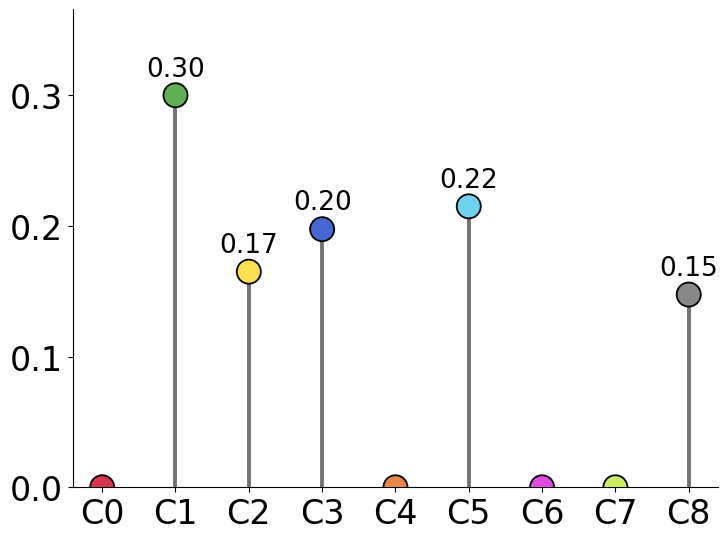

In [40]:
# BASELINE (UNFORCED) DYNAMICS — panels saved INDIVIDUALLY, identical styling to C6.
#   (a) residence  (b) transition matrix  (d) conditional-dwell matrix
#   + edge list export.   NO forcing-law panel (baseline is unforced).
#   Times in SHEDDING CYCLES via T_shed from timescales.npy.
#   Reads ONLY the bl_* variables from the BASELINE MARKOV cell directly above.
#   (Previously it read the un-prefixed globals, which still held the C6 results.)

from matplotlib.colors import LinearSegmentedColormap, Normalize, to_hex
from matplotlib.patches import Rectangle

assert 'bl_mean_residence' in globals(), "run the BASELINE MARKOV cell first"

OUT = "baseline_law_results"; os.makedirs(OUT, exist_ok=True)               # <<< baseline folder
K = 9
ORDER  = [1, 2, 3, 5, 8, 0, 4, 6, 7]      # disc | C0 | branch
olabel = [f'C{k}' for k in ORDER]
PFLOOR = 0.20
N_MIN  = 10

ts = np.load('timescales.npy', allow_pickle=True).item()
T_SHED = ts['T_shed']
tu2cyc = lambda x: x / T_SHED

FS_LBL, FS_TICK, FS_TITLE, FS_NUM = 20, 24, 20, 19    # identical to C6

# (a) RESIDENCE
fig, ax = plt.subplots(figsize=(7.5, 5.6), facecolor='white')
ks   = list(range(K))
vals = [tu2cyc(bl_mean_residence[k]) for k in ks]        # <- shedding cycles
_, stem, _ = ax.stem(ks, vals, basefmt=' ')
plt.setp(stem, color='0.45', linewidth=2.8)
ax.scatter(ks, vals, s=300, c=[cluster_colors[k] for k in ks],
           edgecolors='black', linewidths=1.3, zorder=5)
LBL_LIFT = 0.035                                       # <<< how far up the numbers sit
mx = max(vals) if max(vals) > 0 else 1.0
for k, v in zip(ks, vals):
    if v > 0:
        ax.text(k, v + LBL_LIFT*mx, f'{v:.2f}', ha='center', va='bottom', fontsize=FS_NUM)
ax.set_xticks(ks); ax.set_xticklabels([f'C{k}' for k in ks], fontsize=FS_TICK)
ax.tick_params(axis='y', labelsize=FS_TICK)
#ax.set_ylabel(r'$\tau_k$  (shedding cycles)', fontsize=FS_LBL)   # <<< y-label off, like C6
ax.set_ylim(0, mx * 1.22)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
fig.tight_layout()

#fig.savefig(f'{OUT}/a_residence.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

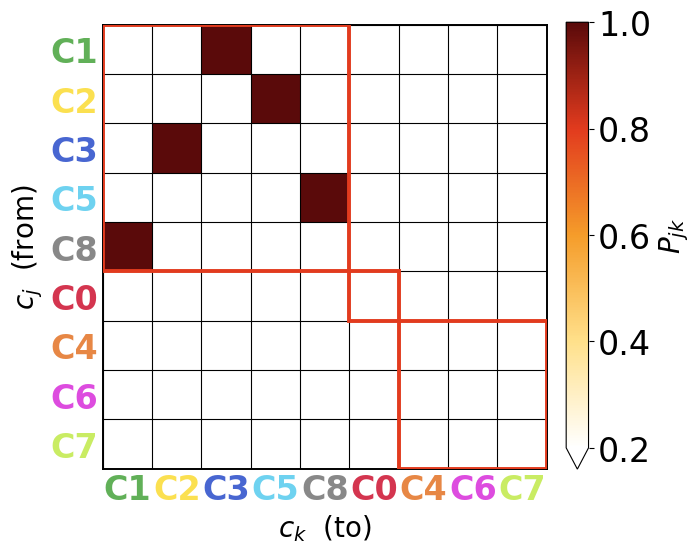

In [41]:
#(b) TRANSITION MATRIX
fig, ax = plt.subplots(figsize=(7.0, 6.2), facecolor='white')
P = bl_transition_prob[np.ix_(ORDER, ORDER)]
hot = LinearSegmentedColormap.from_list('hot_w', ['white', '#ffe08a', '#f59c2a', '#e23b1e', '#5a0a0a'])
im = ax.imshow(P, cmap=hot, norm=Normalize(vmin=PFLOOR, vmax=1.0), origin='upper')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(olabel, fontsize=FS_TICK); ax.set_yticklabels(olabel, fontsize=FS_TICK)
for t, k in zip(ax.get_xticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
for t, k in zip(ax.get_yticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
ax.set_xticks(np.arange(-.5, K, 1), minor=True); ax.set_yticks(np.arange(-.5, K, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.8); ax.tick_params(which='both', length=0)
for sp in ax.spines.values(): sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.4)
for lo, hi in [(-.5, 4.5), (4.5, 5.5), (5.5, 8.5)]:
    ax.add_patch(Rectangle((lo, lo), hi-lo, hi-lo, fill=False, edgecolor='#e23b1e', linewidth=2.8, zorder=10))
ax.set_xlabel(r'$c_k$  (to)', fontsize=FS_LBL); ax.set_ylabel(r'$c_j$  (from)', fontsize=FS_LBL)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, extend='min')
cb.set_label(r'$P_{jk}$', fontsize=FS_LBL); cb.ax.tick_params(labelsize=FS_TICK)
fig.tight_layout();
#fig.savefig(f'{OUT}/b_transition.png', dpi=300, facecolor='white', bbox_inches='tight')

plt.show()

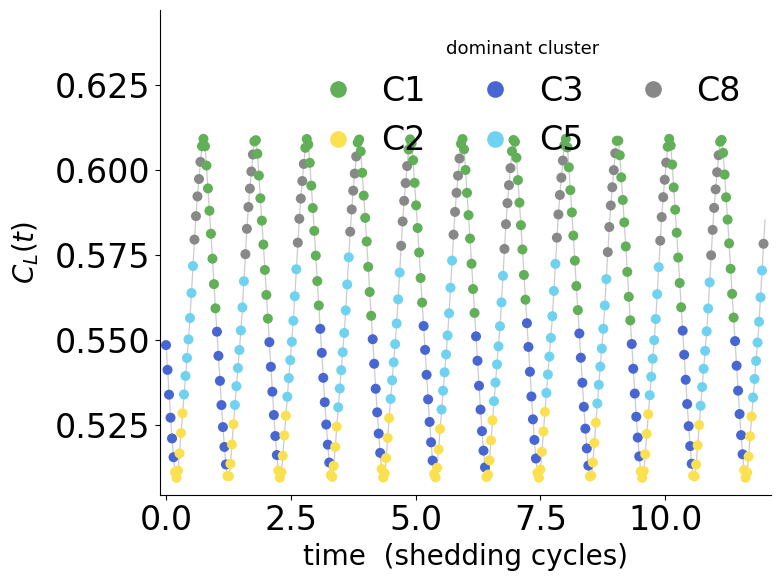

cluster  n_snap     <CL>     <CD>  <CL>/<CD>
C1          110    0.588    0.291      2.021
C2           66    0.516    0.282      1.826
C3           79    0.532    0.284      1.876
C5           86    0.550    0.287      1.914
C8           59    0.591    0.292      2.023


In [42]:
#(c) BASELINE C_L(t) COLOURED BY DOMINANT CLUSTER  (baseline analogue of the forcing-law panel)
# The baseline is unforced, so instead of b(t) we plot the lift from
# ./data/baseline/rot_sensor_data.txt (cols: 0=iter, 1=CD, 2=CL, as in the sensor cell above),
# with a dot at every encoded snapshot coloured by its assigned cluster.
# Same figure size / fonts / legend styling as the C6 panel (c).
from matplotlib.lines import Line2D

bl_sens = np.loadtxt(BL_SENSOR)
s_it, s_cd, s_cl = bl_sens[:, 0].astype(int), bl_sens[:, 1], bl_sens[:, 2]
in_win = (s_it >= IT_START) & (s_it < IT_END)
s_it, s_cd, s_cl = s_it[in_win], s_cd[in_win], s_cl[in_win]

# sensor value at each encoded snapshot iteration
pos = np.searchsorted(s_it, bl_iters)
ok  = (pos < len(s_it)) & (s_it[np.minimum(pos, len(s_it) - 1)] == bl_iters)
if not ok.all():
    print(f"note: {int((~ok).sum())} snapshot iterations have no exact sensor row (skipped in dots)")
snap_cl, snap_cd, snap_lab = s_cl[pos[ok]], s_cd[pos[ok]], bl_labels[ok]
snap_cyc = tu2cyc((bl_iters[ok] - IT_START) * DT_ITER)

fig, ax = plt.subplots(figsize=(8, 6.0), facecolor='white')
ax.plot(tu2cyc((s_it - IT_START) * DT_ITER), s_cl, color='0.8', lw=0.9, zorder=1)
ax.scatter(snap_cyc, snap_cl, s=52, c=[cluster_colors[k] for k in snap_lab],
           edgecolors='none', zorder=2)
ax.set_xlabel('time  (shedding cycles)', fontsize=FS_LBL)
ax.set_ylabel(r'$C_L(t)$', fontsize=FS_LBL, labelpad=10)
ax.tick_params(labelsize=FS_TICK); ax.margins(x=0.01)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + 0.30 * (hi - lo))      # headroom for the legend
visited = sorted(set(snap_lab.tolist()))
ax.legend(handles=[Line2D([0], [0], marker='o', color='none', markerfacecolor=cluster_colors[k],
                          markeredgecolor='none', markersize=12, label=f'C{k}') for k in visited],
          loc='upper right', fontsize=FS_TICK, ncol=3, frameon=False,
          title='dominant cluster', columnspacing=1.1, handletextpad=0.3)
fig.tight_layout()
# fig.savefig(f'{OUT}/c_cl_timeseries.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

# per-cluster aerodynamics of the BASELINE trajectory (at snapshot times)
print(f"{'cluster':<8}{'n_snap':>7}{'<CL>':>9}{'<CD>':>9}{'<CL>/<CD>':>11}")
for k in range(K):
    m = snap_lab == k
    if m.any():
        print(f"C{k:<7}{int(m.sum()):>7}{snap_cl[m].mean():>9.3f}{snap_cd[m].mean():>9.3f}"
              f"{snap_cl[m].mean() / snap_cd[m].mean():>11.3f}")


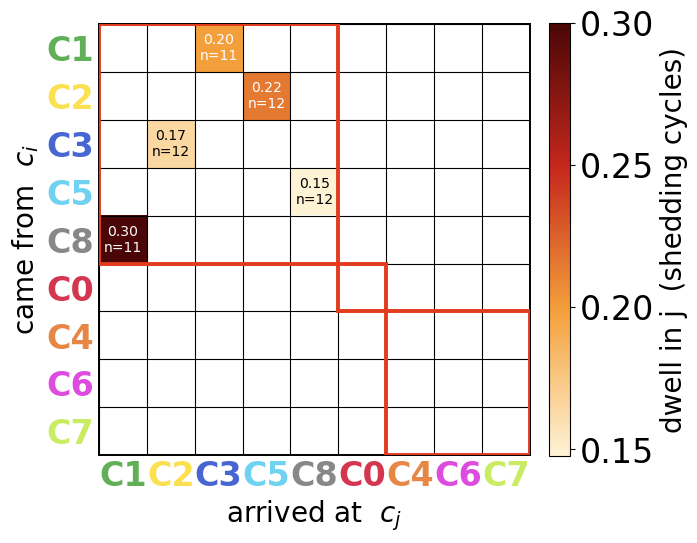

In [43]:
#(d) CONDITIONAL DWELL MATRIX
Tcd = np.full((K, K), np.nan)
for i in range(K):
    for j in range(K):
        if len(bl_conditional_dwell[i][j]) >= N_MIN:
            Tcd[i, j] = tu2cyc(bl_T_conditional[i, j])
Tshow = Tcd[np.ix_(ORDER, ORDER)]
fig, ax = plt.subplots(figsize=(7.2, 6.4), facecolor='white')
cmap = LinearSegmentedColormap.from_list('dwell', ['#fff3d6', '#f4a13c', '#c5281c', '#4a0606'])
cmap.set_bad('white')
im = ax.imshow(np.ma.masked_invalid(Tshow), cmap=cmap, origin='upper')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(olabel, fontsize=FS_TICK); ax.set_yticklabels(olabel, fontsize=FS_TICK)
for t, k in zip(ax.get_xticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
for t, k in zip(ax.get_yticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
vmax = np.nanmax(Tshow) if np.isfinite(np.nanmax(Tshow)) else 1.0
for ii in range(K):
    for jj in range(K):
        v = Tshow[ii, jj]
        if not np.isnan(v):
            n = len(bl_conditional_dwell[ORDER[ii]][ORDER[jj]])
            ax.text(jj, ii, f'{v:.2f}\nn={n}', ha='center', va='center',
                    fontsize=10, color='white' if v > vmax*0.6 else 'black')
ax.set_xticks(np.arange(-.5, K, 1), minor=True); ax.set_yticks(np.arange(-.5, K, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.8); ax.tick_params(which='both', length=0)
for sp in ax.spines.values(): sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.4)
for lo, hi in [(-.5, 4.5), (4.5, 5.5), (5.5, 8.5)]:
    ax.add_patch(Rectangle((lo, lo), hi-lo, hi-lo, fill=False, edgecolor='#e23b1e', linewidth=2.8, zorder=10))
ax.set_xlabel(r'arrived at  $c_j$', fontsize=FS_LBL); ax.set_ylabel(r'came from  $c_i$', fontsize=FS_LBL)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('dwell in j  (shedding cycles)', fontsize=FS_LBL); cb.ax.tick_params(labelsize=FS_TICK)
fig.tight_layout(); 

# fig.savefig(f'{OUT}/d_conditional_dwell.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

In [44]:
# edge list for the OmniGraffle graph (n>=N_MIN) — SAME scaling as C0/C6
DWELL_LO, DWELL_HI = 0.0, 1.2               # <<< MUST match C0 & C6 graphs
dcmap = LinearSegmentedColormap.from_list('dwell', ['#fff3d6','#f4a13c','#c5281c','#4a0606'])
dnorm = Normalize(vmin=DWELL_LO, vmax=DWELL_HI)
width_pt  = lambda Pv: Pv * 10.0            # <<< P*10, same as C0/C6
dwell_hex = lambda d: to_hex(dcmap(dnorm(np.clip(d, DWELL_LO, DWELL_HI))))

rows = []
for i in range(K):
    for j in range(K):
        n = len(bl_conditional_dwell[i][j])
        if n >= N_MIN:
            rows.append((i, j, bl_transition_prob[i, j], tu2cyc(bl_T_conditional[i, j]), n))
rows.sort(key=lambda r: -r[2])
print(f"{'edge':<10}{'width_pt':>9}{'dwell_cyc':>11}{'hex':>9}{'n':>5}")
with open(f'{OUT}/edge_list.csv', 'w') as fcsv:
    fcsv.write("from,to,P,width_pt,dwell_cycles,hex_color,n\n")
    for i, j, p, d, n in rows:
        print(f"C{i}->C{j:<5}{width_pt(p):>9.1f}{d:>11.3f}{dwell_hex(d):>9}{n:>5}")
        fcsv.write(f"C{i},C{j},{p:.4f},{width_pt(p):.2f},{d:.4f},{dwell_hex(d)},{n}\n")
print(f"\nsaved panels + edge_list.csv to ./{OUT}/")

# edges that exist but were cut by N_MIN (baseline = ONE run, C6 pooled 14 -> counts are much smaller)
below = sorted([(i, j, bl_transition_prob[i, j], len(bl_conditional_dwell[i][j]))
                for i in range(K) for j in range(K)
                if 0 < len(bl_conditional_dwell[i][j]) < N_MIN], key=lambda r: -r[2])
if below:
    print(f"\nedges below N_MIN={N_MIN} (NOT in the CSV / dwell matrix):")
    for i, j, p, n in below:
        print(f"  C{i}->C{j:<5} P={p:.3f}  n={n}")

edge       width_pt  dwell_cyc      hex    n
C1->C3         10.0      0.199  #faca8a   11
C2->C5         10.0      0.215  #f9c884   12
C3->C2         10.0      0.165  #fad197   12
C5->C8         10.0      0.147  #fbd59e   12
C8->C1         10.0      0.300  #f7b562   11

saved panels + edge_list.csv to ./baseline_law_results/


## Loading the C0 Forcing laws

In [45]:
# C0-HOLD MARKOV ANALYSIS — run BEFORE the c0 plotting cell.
# Produces: mean_residence, transition_prob, conditional_dwell, T_conditional
# Same method as C6; only the paths/label change. Keeps everything comparable.

# top 10 C0 hold laws (same mechanism: C0-targeting hold / lock-on)
sim_paths = [
    "./data/top_c0_runs/classic-sweep-4/snapshots/",
    "./data/top_c0_runs/snowy-sweep-35/snapshots/",
    "./data/top_c0_runs/ruby-sweep-26/snapshots/",
    "./data/top_c0_runs/expert-sweep-21/snapshots/",
    "./data/top_c0_runs/jolly-sweep-11/snapshots/",
    "./data/top_c0_runs/colorful-sweep-19/snapshots/",
    "./data/top_c0_runs/celestial-sweep-5/snapshots/",
    "./data/top_c0_runs/efficient-sweep-16/snapshots/",
    "./data/top_c0_runs/young-sweep-36/snapshots/",
    "./data/top_c0_runs/glowing-sweep-25/snapshots/",
]

idx = np.arange(80_000, 100_000, 50)
K   = 9
dt_snapshot = 50 * 0.001          # 0.05 t.u. per snapshot

# encode each run, assign each snapshot to nearest centroid
all_runs_assignments = []
for sim_path in sim_paths:
    run_assignments = []
    for value in idx:
        image_path = os.path.join(sim_path, f"snapshot_{value:06d}.png")
        if not os.path.exists(image_path):
            continue
        processed_image = (
            torch.tensor(load_file(image_path), dtype=torch.float32) / 255.0
        ).permute(2, 0, 1).unsqueeze(0)
        mean = model.encode(processed_image)
        dist_ = torch.sum((mean - centroids_d8_k9) ** 2, axis=1)
        run_assignments.append(torch.argmin(dist_).item())
    all_runs_assignments.append(run_assignments)

# transition matrix (pooled, never crossing run boundaries)
transition_matrix = np.zeros((K, K))
for run_assignments in all_runs_assignments:
    for i in range(len(run_assignments) - 1):
        ci, cj = run_assignments[i], run_assignments[i + 1]
        if ci != cj:
            transition_matrix[ci, cj] += 1
row_sums = transition_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
transition_prob = transition_matrix / row_sums

# mean residence per visit
residence_times = {k: [] for k in range(K)}
for run_assignments in all_runs_assignments:
    for cluster_id, group in groupby(run_assignments):
        count = sum(1 for _ in group)
        residence_times[cluster_id].append(count * dt_snapshot)
mean_residence = {k: (np.mean(v) if v else 0.0) for k, v in residence_times.items()}

# conditional dwell T[i->j]
runs_list_per_run = []
for run_assignments in all_runs_assignments:
    runs_list = []
    for cluster_id, group in groupby(run_assignments):
        count = sum(1 for _ in group)
        runs_list.append((cluster_id, count * dt_snapshot))
    runs_list_per_run.append(runs_list)

conditional_dwell = {i: {j: [] for j in range(K)} for i in range(K)}
for runs_list in runs_list_per_run:
    for r in range(1, len(runs_list)):
        i, _    = runs_list[r - 1]
        j, dwell = runs_list[r]
        if i != j:
            conditional_dwell[i][j].append(dwell)

T_conditional = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        if conditional_dwell[i][j]:
            T_conditional[i][j] = np.mean(conditional_dwell[i][j])

# sanity print — expect a single C0 tower, everything else small/zero
print("mean residence (t.u.):")
for k in range(K):
    print(f"  C{k}: {mean_residence[k]:.3f}   (n_visits={len(residence_times[k])})")
print(f"\nencoded {sum(len(r) for r in all_runs_assignments)} snapshots "
      f"across {len(all_runs_assignments)} runs")

# helper to pick the representative hold law: least forcing variation = cleanest lock-on
print("\nforcing variability per run (low std = steadiest hold):")
for sp in sim_paths:
    rd = os.path.dirname(sp.rstrip('/'))
    fp = os.path.join(rd, "rbf_forcing.txt")
    if os.path.exists(fp):
        vals = []
        with open(fp) as f:
            next(f)
            for line in f:
                pr = line.strip().split(',')
                if len(pr) >= 2: vals.append(float(pr[1]))
        vals = np.array(vals)
        if len(vals):
            print(f"  {os.path.basename(rd):<22} std={vals.std():.4f} mean={vals.mean():.4f}")

mean residence (t.u.):
  C0: 17.110   (n_visits=10)
  C1: 0.485   (n_visits=10)
  C2: 0.287   (n_visits=20)
  C3: 0.348   (n_visits=20)
  C4: 0.000   (n_visits=0)
  C5: 0.305   (n_visits=20)
  C6: 0.000   (n_visits=0)
  C7: 0.000   (n_visits=0)
  C8: 0.263   (n_visits=20)

encoded 4000 snapshots across 10 runs

forcing variability per run (low std = steadiest hold):
  classic-sweep-4        std=0.0017 mean=0.0466
  snowy-sweep-35         std=0.0023 mean=0.0455
  ruby-sweep-26          std=0.0014 mean=0.0469
  expert-sweep-21        std=0.0037 mean=0.0528
  jolly-sweep-11         std=0.0039 mean=0.0490
  colorful-sweep-19      std=0.0081 mean=0.0536
  celestial-sweep-5      std=0.0011 mean=0.0542
  efficient-sweep-16     std=0.0145 mean=0.0397
  young-sweep-36         std=0.0060 mean=0.0385
  glowing-sweep-25       std=0.0010 mean=0.0496


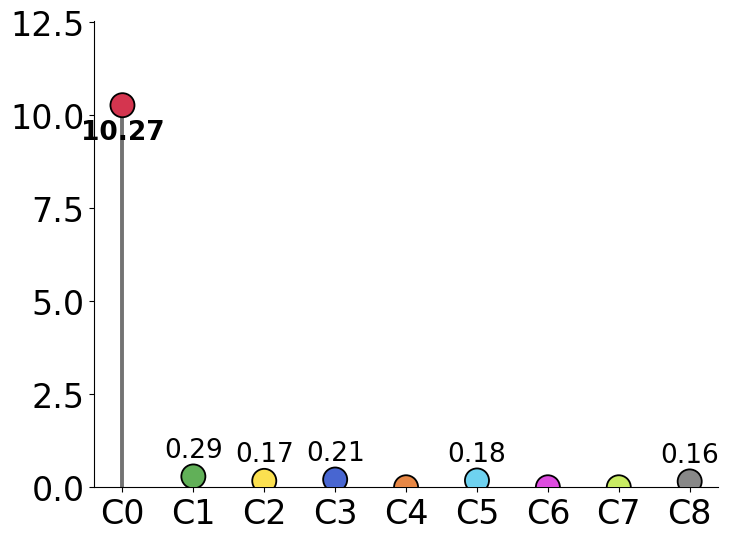

In [46]:
# C0 HOLD LAW — four panels saved INDIVIDUALLY for OmniGraffle assembly.
#   Identical styling/sizes/fonts to the C6 figure (paired comparison).
#   Run AFTER the C0 (runs_c0, top-10) Markov cell. Times in SHEDDING CYCLES.

from matplotlib.colors import LinearSegmentedColormap, Normalize, to_hex
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from functions import load_file

OUT = "C0_law_results"; os.makedirs(OUT, exist_ok=True)                       # <<< C0 folder
REP_RUN_DIR = "./data/top_c0_runs/classic-sweep-4"  # <<< steadiest run (swap per std print)
REP_SNAPS   = os.path.join(REP_RUN_DIR, "snapshots")
DT_ITER = 0.001
K = 9
ORDER  = [1, 2, 3, 5, 8, 0, 4, 6, 7]      # disc | C0 | branch
olabel = [f'C{k}' for k in ORDER]
PFLOOR = 0.20
N_MIN  = 10

ts = np.load('timescales.npy', allow_pickle=True).item()
T_SHED = ts['T_shed']
tu2cyc = lambda x: x / T_SHED

FS_LBL, FS_TICK, FS_TITLE, FS_NUM = 20, 24, 20, 19    # identical to C6

# (a) RESIDENCE
fig, ax = plt.subplots(figsize=(7.5, 5.6), facecolor='white')
ks   = list(range(K))
vals = [tu2cyc(mean_residence[k]) for k in ks]        # <- shedding cycles
_, stem, _ = ax.stem(ks, vals, basefmt=' ')
plt.setp(stem, color='0.45', linewidth=2.8)
ax.scatter(ks, vals, s=300, c=[cluster_colors[k] for k in ks],
           edgecolors='black', linewidths=1.3, zorder=5)
LBL_LIFT = 0.035                                       # <<< how far up the numbers sit
mx = max(vals)
for k, v in zip(ks, vals):
    if v <= 0:
        continue
    if v == mx:
        # tallest marker (the C0 tower): label BELOW so it never hits the top spine
        ax.text(k, v - LBL_LIFT*mx, f'{v:.2f}', ha='center', va='top',
                fontsize=FS_NUM, fontweight='bold', zorder=6)
    else:
        ax.text(k, v + LBL_LIFT*mx, f'{v:.2f}', ha='center', va='bottom',
                fontsize=FS_NUM, zorder=6)
ax.set_xticks(ks); ax.set_xticklabels([f'C{k}' for k in ks], fontsize=FS_TICK)
ax.tick_params(axis='y', labelsize=FS_TICK)
#ax.set_ylabel(r'$\tau_k$  (shedding cycles)', fontsize=FS_LBL)   # y-label off, like C6
ax.set_ylim(0, mx * 1.22)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
fig.tight_layout(); 
# fig.savefig(f'{OUT}/a_residence.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

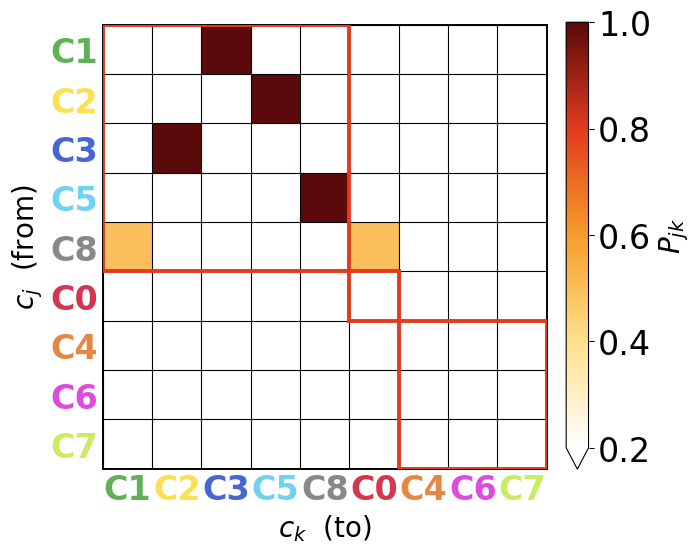

In [47]:
#(b) TRANSITION MATRIX
fig, ax = plt.subplots(figsize=(7.0, 6.2), facecolor='white')
P = transition_prob[np.ix_(ORDER, ORDER)]
hot = LinearSegmentedColormap.from_list('hot_w', ['white', '#ffe08a', '#f59c2a', '#e23b1e', '#5a0a0a'])
im = ax.imshow(P, cmap=hot, norm=Normalize(vmin=PFLOOR, vmax=1.0), origin='upper')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(olabel, fontsize=FS_TICK); ax.set_yticklabels(olabel, fontsize=FS_TICK)
for t, k in zip(ax.get_xticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
for t, k in zip(ax.get_yticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
ax.set_xticks(np.arange(-.5, K, 1), minor=True); ax.set_yticks(np.arange(-.5, K, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.8); ax.tick_params(which='both', length=0)
for sp in ax.spines.values(): sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.4)
for lo, hi in [(-.5, 4.5), (4.5, 5.5), (5.5, 8.5)]:
    ax.add_patch(Rectangle((lo, lo), hi-lo, hi-lo, fill=False, edgecolor='#e23b1e', linewidth=2.8, zorder=10))
ax.set_xlabel(r'$c_k$  (to)', fontsize=FS_LBL); ax.set_ylabel(r'$c_j$  (from)', fontsize=FS_LBL)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, extend='min')
cb.set_label(r'$P_{jk}$', fontsize=FS_LBL); cb.ax.tick_params(labelsize=FS_TICK)
fig.tight_layout();

#fig.savefig(f'{OUT}/b_transition.png', dpi=300, facecolor='white', bbox_inches='tight');
plt.show()

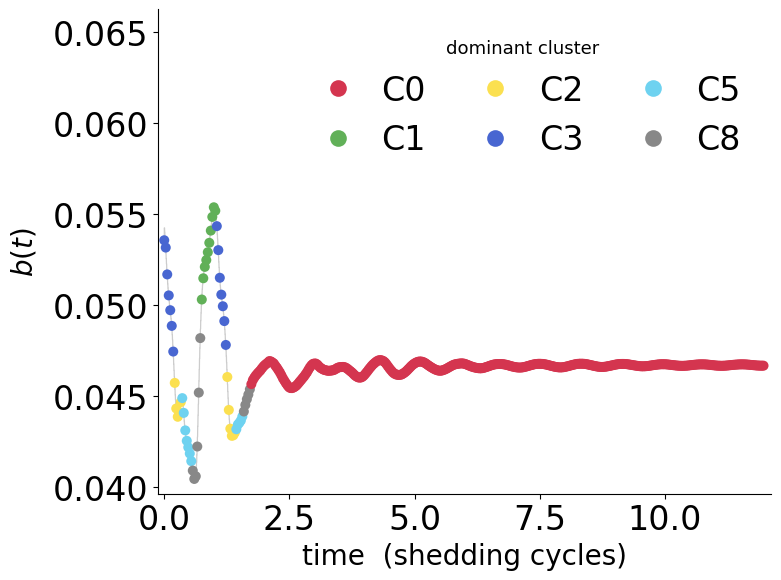

In [48]:
#(c) REPRESENTATIVE FORCING LAW
it, up = [], []
with open(os.path.join(REP_RUN_DIR, "rbf_forcing.txt")) as f:
    next(f)
    for line in f:
        p = line.strip().split(',')
        if len(p) >= 2: it.append(int(p[0])); up.append(float(p[1]))
it = np.array(it); up = np.array(up)
t_cyc = tu2cyc((it - it[0]) * DT_ITER)     # elapsed cycles from window start (0-based)
dom = np.full(len(it), -1, dtype=int)
model.eval()
with torch.no_grad():
    for n, value in enumerate(it):
        ip = os.path.join(REP_SNAPS, f"snapshot_{int(value):06d}.png")
        if not os.path.exists(ip): continue
        img = (torch.tensor(load_file(ip), dtype=torch.float32)/255.0).permute(2,0,1).unsqueeze(0)
        z = model.encode(img)
        dom[n] = int(torch.argmin(torch.sum((z - centroids_d8_k9)**2, axis=1)).item())
fig, ax = plt.subplots(figsize=(8, 6.0), facecolor='white')
ax.plot(t_cyc, up, color='0.8', lw=0.9, zorder=1)
good = dom >= 0
ax.scatter(t_cyc[good], up[good], s=52, c=[cluster_colors[k] for k in dom[good]], edgecolors='none', zorder=2)
ax.set_xlabel('time  (shedding cycles)', fontsize=FS_LBL)
ax.set_ylabel(r'$b(t)$', fontsize=FS_LBL, labelpad=10)
ax.tick_params(labelsize=FS_TICK); ax.margins(x=0.01)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
ax.set_ylim(top=ax.get_ylim()[1] * 1.18)                 # headroom so legend clears the curve
visited = sorted(set(dom[good].tolist()))
ncol = 3                                                  # 3 per row (3+3 layout)
ax.legend(handles=[Line2D([0],[0], marker='o', color='none', markerfacecolor=cluster_colors[k],
                          markeredgecolor='none', markersize=12, label=f'C{k}') for k in visited],
          loc='upper right', fontsize=FS_TICK, ncol=ncol, frameon=False,
          title='dominant cluster', columnspacing=1.1, handletextpad=0.3)
fig.tight_layout(); 
# fig.savefig(f'{OUT}/c_forcing_law.png', dpi=300, facecolor='white', bbox_inches='tight'); 

plt.show()

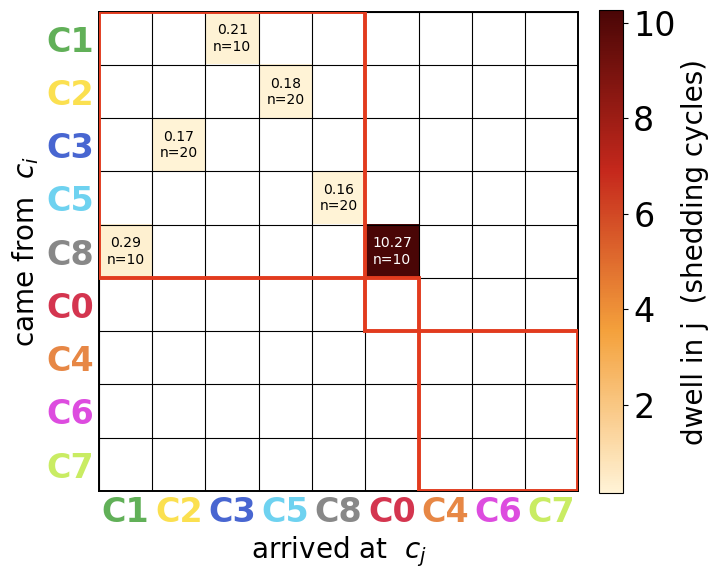

edge       width_pt  dwell_cyc      hex    n
C1->C3         10.0      0.207  #f9c986   10
C2->C5         10.0      0.183  #facd8f   20
C3->C2         10.0      0.173  #fad095   20
C5->C8         10.0      0.158  #fbd39a   20
C8->C0          5.0     10.266  #4a0606   10
C8->C1          5.0      0.291  #f7b766   10

saved panels + edge_list.csv to ./C0_law_results/


In [49]:
#(d) CONDITIONAL DWELL MATRIX
Tcd = np.full((K, K), np.nan)
for i in range(K):
    for j in range(K):
        if len(conditional_dwell[i][j]) >= N_MIN:
            Tcd[i, j] = tu2cyc(T_conditional[i, j])
Tshow = Tcd[np.ix_(ORDER, ORDER)]
fig, ax = plt.subplots(figsize=(7.2, 6.4), facecolor='white')
cmap = LinearSegmentedColormap.from_list('dwell', ['#fff3d6', '#f4a13c', '#c5281c', '#4a0606'])
cmap.set_bad('white')
im = ax.imshow(np.ma.masked_invalid(Tshow), cmap=cmap, origin='upper')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(olabel, fontsize=FS_TICK); ax.set_yticklabels(olabel, fontsize=FS_TICK)
for t, k in zip(ax.get_xticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
for t, k in zip(ax.get_yticklabels(), ORDER): t.set_color(cluster_colors[k]); t.set_fontweight('bold')
mm = np.nanmax(Tshow) if np.isfinite(np.nanmax(Tshow)) else 1.0
for ii in range(K):
    for jj in range(K):
        v = Tshow[ii, jj]
        if not np.isnan(v):
            n = len(conditional_dwell[ORDER[ii]][ORDER[jj]])
            ax.text(jj, ii, f'{v:.2f}\nn={n}', ha='center', va='center',
                    fontsize=10, color='white' if v > mm*0.6 else 'black')
ax.set_xticks(np.arange(-.5, K, 1), minor=True); ax.set_yticks(np.arange(-.5, K, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=0.8); ax.tick_params(which='both', length=0)
for sp in ax.spines.values(): sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.4)
for lo, hi in [(-.5, 4.5), (4.5, 5.5), (5.5, 8.5)]:
    ax.add_patch(Rectangle((lo, lo), hi-lo, hi-lo, fill=False, edgecolor='#e23b1e', linewidth=2.8, zorder=10))
ax.set_xlabel(r'arrived at  $c_j$', fontsize=FS_LBL); ax.set_ylabel(r'came from  $c_i$', fontsize=FS_LBL)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('dwell in j  (shedding cycles)', fontsize=FS_LBL); cb.ax.tick_params(labelsize=FS_TICK)
fig.tight_layout(); fig.savefig(f'{OUT}/d_conditional_dwell.png', dpi=300, facecolor='white', bbox_inches='tight'); plt.show()

# edge list for the OmniGraffle graph (n>=N_MIN) — SAME scaling as C6/baseline
DWELL_LO, DWELL_HI = 0.0, 1.2               # <<< MUST match C6 & baseline graphs
dcmap = LinearSegmentedColormap.from_list('dwell', ['#fff3d6','#f4a13c','#c5281c','#4a0606'])
dnorm = Normalize(vmin=DWELL_LO, vmax=DWELL_HI)
width_pt  = lambda Pv: Pv * 10.0            # <<< P*10, same as C6
dwell_hex = lambda d: to_hex(dcmap(dnorm(np.clip(d, DWELL_LO, DWELL_HI))))

rows = []
for i in range(K):
    for j in range(K):
        n = len(conditional_dwell[i][j])
        if n >= N_MIN:
            rows.append((i, j, transition_prob[i, j], tu2cyc(T_conditional[i, j]), n))
rows.sort(key=lambda r: -r[2])
print(f"{'edge':<10}{'width_pt':>9}{'dwell_cyc':>11}{'hex':>9}{'n':>5}")
with open(f'{OUT}/edge_list.csv', 'w') as fcsv:
    fcsv.write("from,to,P,width_pt,dwell_cycles,hex_color,n\n")
    for i, j, p, d, n in rows:
        print(f"C{i}->C{j:<5}{width_pt(p):>9.1f}{d:>11.3f}{dwell_hex(d):>9}{n:>5}")
        fcsv.write(f"C{i},C{j},{p:.4f},{width_pt(p):.2f},{d:.4f},{dwell_hex(d)},{n}\n")
print(f"\nsaved panels + edge_list.csv to ./{OUT}/")

In [50]:
# EDGE TABLE for the C0-HOLD graph.
# SAME scaling as C6 and baseline — do not change LW or DWELL scales.
import matplotlib.cm as cm

N_MIN  = 10
LW_MIN, LW_MAX = 1.0, 9.0
DWELL_LO, DWELL_HI = 0.0, 2.0          # SAME fixed dwell scale across all 3 regimes
DWELL_CMAP = cm.get_cmap('YlOrRd')
norm = Normalize(vmin=DWELL_LO, vmax=DWELL_HI)
def width_pt(Pv): return LW_MIN + (LW_MAX - LW_MIN) * Pv
def dwell_hex(d): return to_hex(DWELL_CMAP(norm(np.clip(d, DWELL_LO, DWELL_HI))))

edges = []
for i in range(K):
    for j in range(K):
        n = len(conditional_dwell[i][j])
        if n >= N_MIN:
            edges.append((i, j, transition_prob[i, j], T_conditional[i, j], n))
edges.sort(key=lambda e: -e[2])

print(f"C0-HOLD edges (n>={N_MIN}):")
print(f"{'edge':<10}{'P':>6}{'width_pt':>10}{'dwell':>8}{'hex':>10}{'n':>6}")
print("-" * 52)
if not edges:
    print("  (no edges clear n>=10 — the hold law barely transitions: lock-on)")
for i, j, Pv, d, n in edges:
    print(f"C{i}->C{j:<6}{Pv:>6.2f}{width_pt(Pv):>10.2f}{d:>8.2f}{dwell_hex(d):>10}{n:>6}")

# reference scales (draw as legend, same as other graphs)
print("\nDwell color scale:")
for d in [0.0, 0.5, 1.0, 1.5, 2.0]:
    print(f"  dwell {d:.1f} t.u.  ->  {dwell_hex(d)}")
print(f"Width scale: P=0->{LW_MIN}pt,  P=0.5->{width_pt(0.5):.1f}pt,  P=1.0->{LW_MAX}pt")

C0-HOLD edges (n>=10):
edge           P  width_pt   dwell       hex     n
----------------------------------------------------
C1->C3       1.00      9.00    0.35   #ffe590    10
C2->C5       1.00      9.00    0.30   #ffe997    20
C3->C2       1.00      9.00    0.29   #ffea9b    20
C5->C8       1.00      9.00    0.26   #ffec9f    20
C8->C0       0.50      5.00   17.11   #800026    10
C8->C1       0.50      5.00    0.49   #feda78    10

Dwell color scale:
  dwell 0.0 t.u.  ->  #ffffcc
  dwell 0.5 t.u.  ->  #fed976
  dwell 1.0 t.u.  ->  #fd8c3c
  dwell 1.5 t.u.  ->  #e2191c
  dwell 2.0 t.u.  ->  #800026
Width scale: P=0->1.0pt,  P=0.5->5.0pt,  P=1.0->9.0pt


/var/folders/4v/ht8c4jyx1rq_fpb9q8zvhfhw0000gn/T/ipykernel_71474/1824220133.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



# Airfoil and Actuator

surface node (-0.155, 0.096) -> actuator at (-0.155, 0.117)  (offset 0.021)


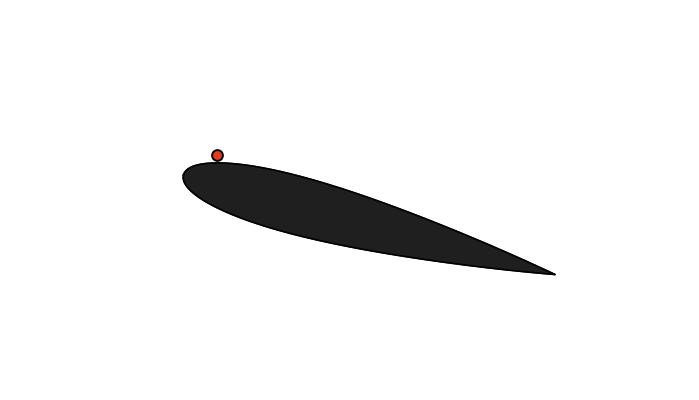

In [51]:
# body.001.inp is ALREADY at 15-deg AoA -> do NOT rotate.
LEN, M = 2.0, 288
delta = LEN / M                       # grid spacing = 2/288 ≈ 0.00694
OFFSET = 3.0 * delta                  # actuator sits 3 cells off the surface (~0.021 chord)

with open("./input/body.001.inp") as f:
    npts = int(f.readline().split()[0]); f.readline()
    xy = np.array([[float(v) for v in f.readline().split()] for _ in range(npts)])
xa, ya = xy[:,0], xy[:,1]

# surface node (grid.f90), then lift by +3*delta in +y (as in grid.f90: y1 = y_node + 3*delta)
ACT_TARGET = (-0.15506977153576368, 0.0960058534614746)
d = (xa - ACT_TARGET[0])**2 + (ya - ACT_TARGET[1])**2
si = np.argmin(d)
ACT_X = xa[si]
ACT_Y = ya[si] + OFFSET               # <<< the 3*delta offset, now included
print(f"surface node ({xa[si]:.3f}, {ya[si]:.3f}) -> actuator at ({ACT_X:.3f}, {ACT_Y:.3f})  (offset {OFFSET:.3f})")

fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor='white')
xf, yf = np.append(xa, xa[0]), np.append(ya, ya[0])
ax.fill(xf, yf, color='0.12', zorder=3)
ax.plot(xf, yf, color='black', lw=1.2, zorder=4)

ax.scatter([ACT_X], [ACT_Y], s=60, marker='o', facecolor='#e23b1e',
           edgecolor='black', linewidths=1.4, zorder=6)

ax.set_aspect('equal')
ax.set_xlim(xa.min()-0.45, xa.max()+0.35)
ax.set_ylim(ya.min()-0.30, ya.max()+0.40)
ax.axis('off')
fig.tight_layout()

#fig.savefig('fig1_airfoil.png', dpi=400, facecolor='white', bbox_inches='tight')
plt.show()

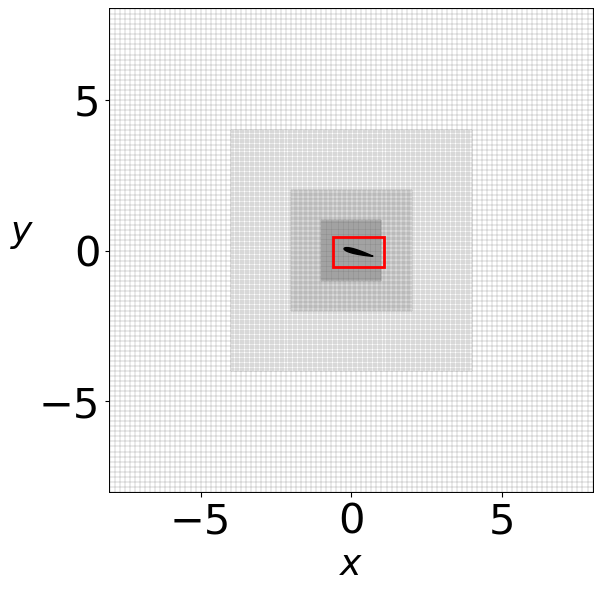

In [52]:
# YOUR multigrid parameters (from your ib.inp)
LEN, M, MGRIDLEV = 2.0, 288, 5          # inner domain [-1,1], 288 cells/level, 5 levels
delta = LEN / M                          # finest cell size = 2/288 ≈ 0.0069
half  = [(LEN/2.0) * 2**k for k in range(MGRIDLEV)]   # half-widths [1,2,4,8,16]
cell  = [delta      * 2**k for k in range(MGRIDLEV)]   # cell size per level (doubles)

# airfoil (already at 15 deg in the .inp)
with open("./input/body.001.inp") as f:
    npts = int(f.readline().split()[0]); f.readline()
    xy = np.array([[float(v) for v in f.readline().split()] for _ in range(npts)])
xa, ya = xy[:,0], xy[:,1]

# knobs
SHOW      = 4          # inner levels to draw (4 -> boxes at ±1,±2,±4,±8)
SUB       = 3          # draw every SUBth real cell line (keeps 288-grid drawable)
LINE_C    = '0.30'     # cell-line grey
LINE_LW   = 0.25       # cell-line width
LINE_A    = 0.65       # cell-line alpha

# FONT SIZES (edit these)
FS_AXLABEL = 26        # <<< x and y AXIS-LABEL fontsize  ('x', 'y')
FS_TICKS   = 30        # <<< x and y TICK-NUMBER fontsize (-5, 0, 5)

fig, ax = plt.subplots(figsize=(6.2, 6.2), facecolor='white')

# WHITE fill, NO box outlines — the density change alone marks each level boundary.
for L in reversed(range(SHOW)):
    h  = half[L]
    dx = cell[L] * SUB
    z  = (SHOW - L) * 10
    ax.add_patch(Rectangle((-h, -h), 2*h, 2*h, facecolor='white',
                           edgecolor='none', zorder=z))
    gl = np.arange(-h, h + dx*0.5, dx)
    ax.vlines(gl, -h, h, color=LINE_C, lw=LINE_LW, alpha=LINE_A, zorder=z+1)
    ax.hlines(gl, -h, h, color=LINE_C, lw=LINE_LW, alpha=LINE_A, zorder=z+1)

# airfoil + red zoom box (on top)
ax.fill(np.append(xa, xa[0]), np.append(ya, ya[0]), color='black', zorder=100)
zx0, zx1 = xa.min()-0.35, xa.max()+0.35
zy0, zy1 = ya.min()-0.35, ya.max()+0.35
ax.add_patch(Rectangle((zx0, zy0), zx1-zx0, zy1-zy0, fill=False,
                       edgecolor='red', linewidth=2.0, zorder=101))

# view
VIEW = half[SHOW-1]                        # ±8 for SHOW=4
ax.set_xlim(-VIEW, VIEW); ax.set_ylim(-VIEW, VIEW); ax.set_aspect('equal')

ax.set_xlabel(r'$x$', fontsize=FS_AXLABEL)                    # <<< x AXIS LABEL size
ax.set_ylabel(r'$y$', fontsize=FS_AXLABEL, rotation=0, labelpad=12)  # <<< y AXIS LABEL size
ax.set_xticks([-5, 0, 5]); ax.set_yticks([-5, 0, 5])
ax.tick_params(axis='both', labelsize=FS_TICKS)              # <<< x & y TICK-NUMBER size
# (removed the stray 'ax.tick_params(labelsize=13)' that was overriding the above)

# keep the OUTER plot border (spines), inner level boxes stay borderless
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.4)

fig.tight_layout()

# fig.savefig('fig1_domain.png', dpi=400, facecolor='white', bbox_inches='tight')
plt.show()

## Aerodynamic Forces - Baseline, $C_0$, and $C_6$

In [53]:
# %matplotlib inline

# Top-10 C6 control laws
c6_paths = [
    "./data/top_c6_runs/wandering-sweep-64/snapshots/",
    "./data/top_c6_runs/charmed-sweep-49/snapshots/",
    "./data/top_c6_runs/quiet-sweep-35/snapshots/",
    "./data/top_c6_runs/mild-sweep-66/snapshots/",
    "./data/top_c6_runs/iconic-sweep-76/snapshots/",
    "./data/top_c6_runs/generous-sweep-65/snapshots/",
    "./data/top_c6_runs/happy-sweep-32/snapshots/",
    "./data/top_c6_runs/worthy-sweep-43/snapshots/",
    "./data/top_c6_runs/apricot-sweep-24/snapshots/",
    "./data/top_c6_runs/fiery-sweep-73/snapshots/",
    "./data/top_c6_runs/proud-sweep-74/snapshots/",
    "./data/top_c6_runs/cosmic-sweep-58/snapshots/",
    "./data/top_c6_runs/vital-sweep-42/snapshots/",
    "./data/top_c6_runs/dainty-sweep-78/snapshots/",
]

# Top-10 C0 control laws
c0_paths = [
    "./data/top_c0_runs/classic-sweep-4/snapshots/",
    "./data/top_c0_runs/snowy-sweep-35/snapshots/",
    "./data/top_c0_runs/ruby-sweep-26/snapshots/",
    "./data/top_c0_runs/expert-sweep-21/snapshots/",
    "./data/top_c0_runs/jolly-sweep-11/snapshots/",
    "./data/top_c0_runs/colorful-sweep-19/snapshots/",
    "./data/top_c0_runs/celestial-sweep-5/snapshots/",
    "./data/top_c0_runs/efficient-sweep-16/snapshots/",
    "./data/top_c0_runs/young-sweep-36/snapshots/",
    "./data/top_c0_runs/glowing-sweep-25/snapshots/",
]


# Convert ".../snapshots/" -> ".../rot_sensor_data.txt"
def sensor_path(path):
    return path.replace("snapshots/", "rot_sensor_data.txt")


def ensemble_clcd(paths):
    ratios = []
    for path in paths:
        data = np.loadtxt(sensor_path(path), delimiter=",", skiprows=1)

        iteration = data[:, 0]
        Cd = data[:, 5]
        Cl = data[:, 6]

        ratios.append(Cl / Cd)
    ratios = np.stack(ratios)
    return iteration, ratios.mean(axis=0), ratios.std(axis=0)



# C6 ensemble
it_c6, mean_c6, std_c6 = ensemble_clcd(c6_paths)

# C0 ensemble
it_c0, mean_c0, std_c0 = ensemble_clcd(c0_paths)



# Baseline
SENSOR_BL = "./data/baseline/rot_sensor_data.txt"   # same folder
d   = np.loadtxt(SENSOR_BL)

it_base = d[:, 0]
Cd_base = d[:, 1]
Cl_base = d[:, 2]

ratio_base = Cl_base / Cd_base

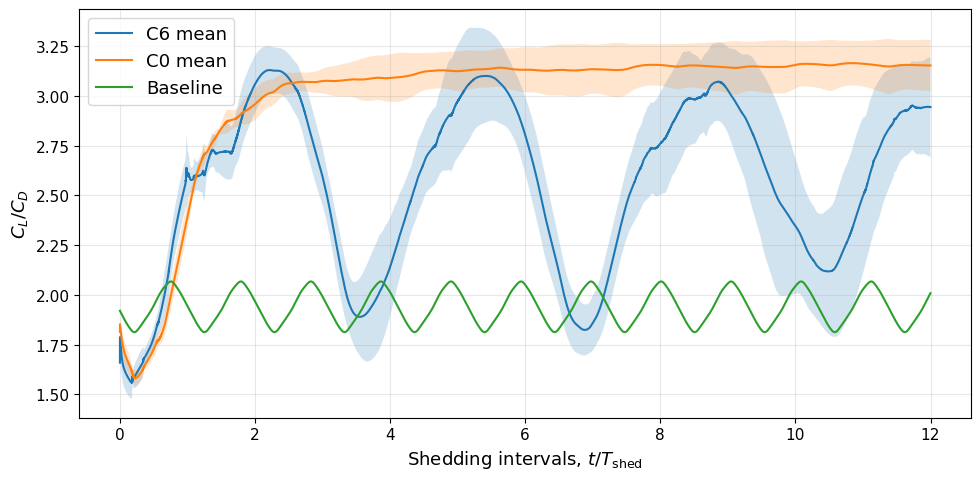

In [54]:
# Convert iteration to shedding intervals
shed_c6  = iter_to_shed(it_c6  - 80000)
shed_c0  = iter_to_shed(it_c0  - 80000)
shed_base = iter_to_shed(it_base - 80000)


plt.figure(figsize=(10, 5))

# C6
plt.plot(shed_c6, mean_c6, label="C6 mean")
plt.fill_between(shed_c6, mean_c6 - std_c6,
    mean_c6 + std_c6, alpha=0.2)

# C0
plt.plot(shed_c0, mean_c0, label="C0 mean")
plt.fill_between(shed_c0, mean_c0 - std_c0,
    mean_c0 + std_c0, alpha=0.2)

# Baseline
plt.plot(shed_base, ratio_base, label="Baseline")

plt.xlabel(r"Shedding intervals, $t/T_{\mathrm{shed}}$")
plt.ylabel(r"$C_L/C_D$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Getting the top control laws statistics for $C_0$ and $C_6$

In [55]:
import pandas as pd

# Top-10 laws exported from W&B
c0_laws = pd.read_csv("./c0_control_laws.csv")
c6_laws = pd.read_csv("./c6_contral_laws.csv")

# Parameters used by the controller
cols = [f"action_{k}" for k in range(9)] + ["sigma"]

def summarize_laws(df):
    return pd.DataFrame({
        "median": df[cols].median(),
        "min":    df[cols].min(),
        "max":    df[cols].max(),
    })

c0_summary = summarize_laws(c0_laws)
c6_summary = summarize_laws(c6_laws)

print("C0 — Hold laws")
display(c0_summary)

print("C6 — Escape laws")
display(c6_summary)

C0 — Hold laws


,median,min,max
action_0,0.034315,0.010746,0.082739
action_1,0.047900,0.012152,0.092412
action_2,0.067655,0.005318,0.096227
action_3,0.014794,0.001323,0.097731
action_4,0.071072,0.028754,0.084841
action_5,0.032886,0.010595,0.084630
action_6,0.052037,0.011463,0.092928
action_7,0.029692,0.004906,0.095767
action_8,0.078931,0.024596,0.095621
sigma,1.514293,0.540010,1.699934


C6 — Escape laws


,median,min,max
action_0,0.001571,0.000039,0.005151
action_1,0.018082,0.000545,0.048401
action_2,0.033108,0.017943,0.097320
action_3,0.073542,0.005633,0.099653
action_4,0.075927,0.018906,0.095409
action_5,0.027660,0.016514,0.054488
action_6,0.048848,0.022553,0.070166
action_7,0.053263,0.029290,0.069605
action_8,0.030761,0.006457,0.088948
sigma,0.298319,0.258952,0.452589


In [56]:
def format_summary(summary):
    return {
        idx: f"{row['median']:.4f} ({row['min']:.4f}--{row['max']:.4f})"
        for idx, row in summary.iterrows()
    }

print("C0 — Hold")
print(format_summary(c0_summary))

print("\nC6 — Escape")
print(format_summary(c6_summary))

C0 — Hold
{'action_0': '0.0343 (0.0107--0.0827)', 'action_1': '0.0479 (0.0122--0.0924)', 'action_2': '0.0677 (0.0053--0.0962)', 'action_3': '0.0148 (0.0013--0.0977)', 'action_4': '0.0711 (0.0288--0.0848)', 'action_5': '0.0329 (0.0106--0.0846)', 'action_6': '0.0520 (0.0115--0.0929)', 'action_7': '0.0297 (0.0049--0.0958)', 'action_8': '0.0789 (0.0246--0.0956)', 'sigma': '1.5143 (0.5400--1.6999)'}

C6 — Escape
{'action_0': '0.0016 (0.0000--0.0052)', 'action_1': '0.0181 (0.0005--0.0484)', 'action_2': '0.0331 (0.0179--0.0973)', 'action_3': '0.0735 (0.0056--0.0997)', 'action_4': '0.0759 (0.0189--0.0954)', 'action_5': '0.0277 (0.0165--0.0545)', 'action_6': '0.0488 (0.0226--0.0702)', 'action_7': '0.0533 (0.0293--0.0696)', 'action_8': '0.0308 (0.0065--0.0889)', 'sigma': '0.2983 (0.2590--0.4526)'}


In [57]:
# T11 — cycle period across the exact top-10 C6 laws from W&B

from pathlib import Path

# Exact top-10 C6 runs from the W&B CSV
c6_top10_paths = [
    f"./data/top_c6_runs/{name}/snapshots/"
    for name in c6_laws["Name"]
]

idx = np.arange(80_000, 100_000, 50)
dt_snapshot = 50 * 0.001

T_SHED = np.load("timescales.npy", allow_pickle=True).item()["T_shed"]

# Assign C6 trajectories to the fixed K=9 centroids
c6_cycle_assignments = []

model.eval()

with torch.no_grad():
    for sim_path in c6_top10_paths:

        labels = []

        for value in idx:
            image_path = os.path.join(
                sim_path, f"snapshot_{value:06d}.png"
            )

            if not os.path.exists(image_path):
                continue

            x = (
                torch.tensor(load_file(image_path), dtype=torch.float32)
                / 255.0
            ).permute(2, 0, 1).unsqueeze(0)

            z = model.encode(x)

            dist = torch.sum(
                (z - centroids_d8_k9) ** 2, dim=1
            )

            labels.append(torch.argmin(dist).item())

        c6_cycle_assignments.append(labels)


# Complete cycle:
# C0 -> ... -> C6 -> ... -> next C0
def cycle_periods(labels):

    labels = np.asarray(labels, dtype=int)

    # Compress consecutive identical cluster labels
    states = []
    starts = []

    for i, k in enumerate(labels):
        if i == 0 or k != labels[i - 1]:
            states.append(k)
            starts.append(i)

    states = np.asarray(states)
    starts = np.asarray(starts)

    c0_visits = np.where(states == 0)[0]
    periods = []

    for a, b in zip(c0_visits[:-1], c0_visits[1:]):

        # Count only complete escape cycles that visit C6
        if 6 in states[a + 1:b]:

            period = (
                (starts[b] - starts[a])
                * dt_snapshot
                / T_SHED
            )

            periods.append(period)

    return np.asarray(periods)



# Period for each optimized law
law_mean_periods = []

print(f"{'law':<24} {'cycles':>7} {'mean T/Tsh':>12} {'std':>10}")
print("-" * 57)

for path, labels in zip(c6_top10_paths, c6_cycle_assignments):

    name = Path(path).parent.name
    periods = cycle_periods(labels)

    if len(periods) > 0:

        law_mean_periods.append(periods.mean())

        print(
            f"{name:<24}"
            f"{len(periods):>7d}"
            f"{periods.mean():>12.3f}"
            f"{periods.std():>10.3f}"
        )

    else:
        print(
            f"{name:<24}"
            f"{0:>7d}"
            f"{'--':>12}"
            f"{'--':>10}"
        )


# Across the ten laws
law_mean_periods = np.asarray(law_mean_periods)

print("\nAcross the top-10 C6 laws:")

if len(law_mean_periods) > 0:

    print(
        f"Mean cycle period = "
        f"{law_mean_periods.mean():.3f} T_sh"
    )

    print(
        f"Std across laws   = "
        f"{law_mean_periods.std(ddof=1):.3f} T_sh"
    )

    print(
        f"Range             = "
        f"{law_mean_periods.min():.3f} -- "
        f"{law_mean_periods.max():.3f} T_sh"
    )

    probe_time = 1.65 + 1.30

    print(
        f"\nEscape + recapture = "
        f"{probe_time:.2f} T_sh"
    )

    print(
        f"Fraction of mean cycle = "
        f"{100 * probe_time / law_mean_periods.mean():.1f}%"
    )

law                       cycles   mean T/Tsh        std
---------------------------------------------------------
wandering-sweep-64            3       2.870     0.597
charmed-sweep-49              3       3.090     0.130
quiet-sweep-35                3       3.020     0.669
mild-sweep-66                 3       2.330     0.649
iconic-sweep-76               3       2.870     0.824
generous-sweep-65             2       3.525     0.165
happy-sweep-32                2       2.520     0.720
worthy-sweep-43               3       3.130     0.014
apricot-sweep-24              4       2.272     0.758
fiery-sweep-73                2       3.270     0.090

Across the top-10 C6 laws:
Mean cycle period = 2.890 T_sh
Std across laws   = 0.408 T_sh
Range             = 2.272 -- 3.525 T_sh

Escape + recapture = 2.95 T_sh
Fraction of mean cycle = 102.1%
